# Construction and Architectural Document Processing Pipeline

## Setup env

In [2]:
import os
import getpass
from uuid import uuid4

os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API Key:")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = f"AIE8 - Certification Challenge - {uuid4().hex[0:8]}"
os.environ["LANGCHAIN_API_KEY"] = getpass.getpass("LangSmith API Key: ")

# needed for running async code in notebook
import nest_asyncio
nest_asyncio.apply()

## Data ingestion

In [3]:
# Env setup
import os
import sys
import json
import logging
from pathlib import Path
from datetime import datetime
from typing import List, Dict, Any, Optional

# Configure logging for debugging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

# Set up paths
PROJECT_ROOT = Path.cwd().parent  # Go up one level from notebooks/
DATA_DIR = PROJECT_ROOT / "data"
PARSED_DATA_DIR = DATA_DIR / "parsed"

### Token counting helpers

In [4]:
import tiktoken

def count_tokens(text: str, model: str = "gpt-4") -> int:
    """
    Count the number of tokens in text using tiktoken.
    
    Args:
        text: The text to count tokens for
        model: The OpenAI model to use for tokenization (default: gpt-4)
    
    Returns:
        Number of tokens
    """
    try:
        encoding = tiktoken.encoding_for_model(model)
        return len(encoding.encode(text))
    except KeyError:
        # Fallback to cl100k_base encoding (used by GPT-4, GPT-3.5-turbo, etc.)
        encoding = tiktoken.get_encoding("cl100k_base")
        return len(encoding.encode(text))

def analyze_document_tokens_with_limits(full_text: str, model: str = "gpt-4-turbo") -> Dict[str, Any]:
    """
    Analyze token count for a document with model limit checking.
    """
    # Model limits (input + output combined)
    MODEL_LIMITS = {
        "gpt-4": 8192,
        "gpt-4-turbo": 128000,
        "gpt-4o": 128000,
        "gpt-4o-mini": 128000,
        "gpt-4.1": 1000000
    }
    
    total_tokens = count_tokens(full_text, model)
    
    model_limit = MODEL_LIMITS.get(model, 128000)  # Default to GPT-4 Turbo limit
    reserved_output_tokens = 2000  # Reserve tokens for response
    
    token_analysis = {
        "model_used": model,
        "total_tokens": total_tokens,
        "model_limit": model_limit,
        "effective_input_limit": model_limit - reserved_output_tokens,
        "fits_in_context": total_tokens <= (model_limit - reserved_output_tokens),
        "utilization_percentage": (total_tokens / (model_limit - reserved_output_tokens)) * 100,
        "recommendation": ""
    }
    
    # Generate recommendations
    if token_analysis["fits_in_context"]:
        if token_analysis["utilization_percentage"] < 50:
            token_analysis["recommendation"] = "✅ Document fits comfortably in context window"
        elif token_analysis["utilization_percentage"] < 80:
            token_analysis["recommendation"] = "⚠️ Document uses significant portion of context window"
        else:
            token_analysis["recommendation"] = "🔶 Document uses most of context window - consider chunking for complex tasks"
    else:
        token_analysis["recommendation"] = f"❌ Document exceeds context limit by {total_tokens - token_analysis['effective_input_limit']:,} tokens - chunking required"
    
    return token_analysis

def print_token_analysis_with_limits(token_analysis: Dict[str, Any]):
    """Print formatted token analysis with limit information."""
    if "error" in token_analysis:
        print(f"❌ {token_analysis['error']}")
        return
    
    print("📊 Token Analysis with Model Limits")
    print("=" * 60)
    print(f"Model: {token_analysis['model_used']}")
    print(f"Document tokens: {token_analysis['total_tokens']:,}")
    print(f"Model limit: {token_analysis['model_limit']:,}")
    print(f"Effective input limit: {token_analysis['effective_input_limit']:,}")
    print(f"Utilization: {token_analysis['utilization_percentage']:.1f}%")
    print(f"Fits in context: {'Yes' if token_analysis['fits_in_context'] else 'No'}")
    print(f"Recommendation: {token_analysis['recommendation']}")

### Document Sectionizer and Chunker logic

In [5]:
import re
import json
import uuid
from dataclasses import dataclass, asdict
from datetime import datetime
from pathlib import Path
from typing import Any, Dict, List, Optional, Callable, Tuple

# ---------------------------------------
# Sectionizer data model
# ---------------------------------------
@dataclass
class Section:
    id: str
    level: int                      # 1 = PART, 2 = ARTICLE, 3 = sub-article (optional)
    header: str
    header_path: List[str]
    page_start: Optional[int]       # Unknown from MD; keep None unless you map later
    page_end: Optional[int]
    text: str                       # concatenated body text for this section

@dataclass
class SectionChunk:
    section_id: str
    header_path: List[str]
    chunk_index: int
    text: str                       # chunked text within the section

# ---------------------------------------
# CSI-aware heuristics
# ---------------------------------------
PART_RE = re.compile(r'^\s*PART\s+(?:[123]|I|II|III)\s*-\s+.+$', re.IGNORECASE)

# ALL-CAPS-ish line (len-limited)
ALLCAPS_RE = re.compile(r'^[A-Z0-9][A-Z0-9 \-/,()&\.]{3,}$')

# Numbered article headings like "1.1 SUMMARY", "2.3 MATERIALS"
NUM_ARTICLE_RE = re.compile(r'^\s*(?P<part>[1-3])\.(?P<art>\d+)\s+(?P<title>[A-Z][A-Z0-9 \-/,()&\.]{2,})\s*$')

# Things that look like list items, not headings: "1.", "1.1.", "a)", "-"
LIST_LIKE_RE = re.compile(r'^\s*(?:\d+(?:\.\d+)*[\.\)]|[a-zA-Z][\.\)])\s+')

CSI_ARTICLE_HINTS = {
    "SUMMARY","REFERENCES","SUBMITTALS","QUALITY ASSURANCE",
    "DELIVERY, STORAGE, AND HANDLING","SEQUENCING","WARRANTY",
    "PERFORMANCE REQUIREMENTS","SYSTEM DESCRIPTION","ELEVATORS",
    "MATERIALS","MANUFACTURERS","PRODUCTS","EXECUTION","INSTALLATION",
    "FIELD QUALITY CONTROL","CAR ENCLOSURES","HOISTWAY ENTRANCES",
    "OPERATION","CAR FIXTURES","HALL FIXTURES","DEFINITIONS"
}

def _looks_like_markdown_heading(line: str):
    m = re.match(r'^(#{1,6})\s+(.+?)\s*$', line.strip())
    if m:
        return True, len(m.group(1)), m.group(2).strip()
    return False, 0, ""

def _normalize_header(text: str) -> str:
    return re.sub(r'\s+', ' ', text.strip())

def _slugify(parts: List[str]) -> str:
    import re as _re
    s = "-".join(parts).lower()
    return _re.sub(r'[^a-z0-9]+', '-', s).strip('-')

def _normalize_header(text: str) -> str:
    return re.sub(r'\s+', ' ', text.strip())

def _slugify(parts: List[str]) -> str:
    s = "-".join(parts)
    s = s.lower()
    s = re.sub(r'[^a-z0-9]+', '-', s).strip('-')
    return s


def sectionize_markdown(md_text: str) -> List[Section]:
    """
    Build sections from Docling-exported Markdown (CSI-aware):
    - PART detection has highest priority (even if it's a Markdown heading).
    - Numbered articles 'x.y TITLE' are anchored under PART x (imputed if missing).
    - ALLCAPS/known-article headings become Article level.
    """
    lines = md_text.splitlines()
    sections: List[Section] = []
    path_stack: List[Tuple[int, str]] = []  # (level, header)
    current: Optional[Section] = None

    def start_section(level: int, header: str):
        nonlocal current, path_stack, sections
        header = _normalize_header(header)
        # pop to parent
        while path_stack and path_stack[-1][0] >= level:
            path_stack.pop()
        path_stack.append((level, header))
        header_path = [h for _, h in path_stack]
        sec_id = f"sec-{_slugify(header_path)}-{uuid.uuid4().hex[:8]}"
        current = Section(
            id=sec_id, level=level, header=header,
            header_path=header_path, page_start=None, page_end=None, text=""
        )
        sections.append(current)

    def ensure_part(part_no: str):
        """Ensure top of stack is PART <part_no>; create an imputed PART if needed."""
        # If current top-level PART is already correct, nothing to do
        for lvl, hdr in reversed(path_stack):
            if lvl == 1:
                # try to detect the number in existing header
                m = re.search(r'\bPART\s+([1-3]|I|II|III)\b', hdr, re.IGNORECASE)
                if m:
                    cur = m.group(1)
                    # Normalize roman <-> arabic (simple)
                    if cur in {"I","II","III"}:
                        cur = {"I":"1","II":"2","III":"3"}[cur]
                    if cur == part_no:
                        return
                # wrong part at level 1 → pop it
                while path_stack and path_stack[-1][0] >= 1:
                    path_stack.pop()
                break
        # Create an imputed PART header if missing
        start_section(1, f"PART {part_no} - GENERAL (IMPUTED)")

    for raw in lines:
        line = raw.rstrip()
        if not line.strip():
            # still attach whitespace to current text to preserve spacing a bit
            if current:
                current.text += "\n"
            continue

        # Check if this is a Markdown heading
        is_md, md_level, md_header = _looks_like_markdown_heading(line)

        # 1) PART has highest priority (even if it's a MD heading)
        if (is_md and PART_RE.match(md_header)) or PART_RE.match(line):
            start_section(1, md_header if is_md else line)
            continue

        # 2) Numbered article like "1.1 SUMMARY" → anchor to PART 1
        m_num = NUM_ARTICLE_RE.match(line.upper())
        if m_num and not LIST_LIKE_RE.match(line):
            ensure_part(m_num.group('part'))  # creates PART if missing
            start_section(2, f"{m_num.group('part')}.{m_num.group('art')} {m_num.group('title')}")
            continue

        # 3) Other Markdown headings (non-PART) → treat as Article/Sub-article
        if is_md:
            # If we have a PART already, make this level 2; else level 1
            level = 2 if any(l == 1 for l, _ in path_stack) else 1
            start_section(level, md_header)
            continue

        # 4) ALLCAPS/known-article headings → Article
        t = line.strip()
        if (t.upper() in CSI_ARTICLE_HINTS or
            (ALLCAPS_RE.match(t) and not LIST_LIKE_RE.match(t) and not t.endswith('.'))):
            level = 2 if any(l == 1 for l, _ in path_stack) else 1
            start_section(level, t)
            continue

        # 5) Content
        if current is None:
            start_section(1, "PREFACE")
        current.text += (line + "\n")

    # Trim text
    for s in sections:
        s.text = s.text.strip()
    return sections


# ---------------------------------------
# Chunker inside sections
# ---------------------------------------
def default_token_count(s: str) -> int:
    # ~4 chars/token rough heuristic
    return max(1, int(len(s) / 4))

def chunk_sections(
    sections: List[Section],
    max_tokens: int = 700,
    overlap_tokens: int = 80,
    token_counter: Optional[Callable[[str], int]] = None
) -> List[SectionChunk]:
    """
    Chunk each section's text to fit LLM limits, with overlap. 
    Splits on paragraphs/sentences when possible.
    """
    tc = token_counter or default_token_count
    chunks: List[SectionChunk] = []

    SENT_SPLIT = re.compile(r'(?<=[\.\:\;])\s+\n?|\n{2,}')  # sentence/paragraph-ish

    for s in sections:
        text = s.text or ""
        if not text.strip():
            continue

        parts = [p.strip() for p in SENT_SPLIT.split(text) if p.strip()]
        buf: List[str] = []
        buf_tokens = 0
        idx = 0

        def flush():
            nonlocal buf, buf_tokens, idx
            if not buf:
                return
            chunk_text = " ".join(buf).strip()
            chunks.append(SectionChunk(
                section_id=s.id,
                header_path=s.header_path,
                chunk_index=idx,
                text=chunk_text
            ))
            idx += 1
            # build overlap
            enc_len = tc(chunk_text)
            # crude: keep last N tokens by truncating characters proportionally
            if enc_len > overlap_tokens:
                keep_ratio = overlap_tokens / enc_len
                keep_chars = max(1, int(len(chunk_text) * keep_ratio))
                overlap_text = chunk_text[-keep_chars:]
            else:
                overlap_text = chunk_text
            buf = [overlap_text]
            buf_tokens = tc(overlap_text)

        for part in parts:
            p_tokens = tc(part)
            if buf_tokens + p_tokens > max_tokens and buf:
                flush()
            buf.append(part)
            buf_tokens += p_tokens

        if buf:
            # final flush without adding overlap
            chunk_text = " ".join(buf).strip()
            chunks.append(SectionChunk(
                section_id=s.id,
                header_path=s.header_path,
                chunk_index=idx,
                text=chunk_text
            ))

    return chunks

### Document conversion (with Docling)

In [6]:
from docling.document_converter import DocumentConverter
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions
from docling.document_converter import PdfFormatOption
from docling.datamodel.pipeline_options import EasyOcrOptions
from docling_core.types.doc import ImageRefMode, PictureItem, TableItem
import pandas as pd

# Configure Docling pipeline options for construction documents
def create_docling_config(full_page_ocr: bool = False):
    """Create Docling configuration optimized for construction documents"""
    
    # PDF pipeline options based on real construction document analysis
    pdf_options = PdfPipelineOptions(
        do_table_structure=True,
        do_ocr=True,
        ocr_options=EasyOcrOptions(
            lang=["en"],  # Specify your language(s)
            confidence_threshold=0.7,  # Higher threshold for better quality
            use_gpu=True,  # Enable GPU acceleration if available
            recog_network="standard",  # Use standard recognition network
            force_full_page_ocr=full_page_ocr # processes each page purely via OCR (often slower than hybrid detection)
        ),
        # RapidOcrOptions(
        #     backend="onnxruntime",  # Fast inference backend
        #     text_score=0.6,  # Higher confidence threshold
        #     force_full_page_ocr=True
        # ),
        # TesseractOcrOptions(
        #     lang=["eng"],
        #     psm=6  # Uniform block of text (good for most documents)
        # )
        # generate_page_images=True,
        # generate_table_images=True,
        generate_picture_images=True,
        images_scale=2.0,  # Higher scale for better text recognition
        force_backend_text=False  # Let OCR generate the text
    )
    
    # Format options
    format_options = {
        InputFormat.PDF: PdfFormatOption(pipeline_options=pdf_options)
    }
    
    return format_options


def parse_document_with_docling(
    converter: DocumentConverter, pdf_path: Path, is_csi_spec: bool = False,
    save_pictures: bool = False, save_tables: bool = False,
    write_artifacts: bool = True,
    token_counter: Optional[Callable[[str], int]] = None) -> Dict[str, Any]:
    """Parse a single PDF document using Docling"""

    document_name = pdf_path.stem
    print(f"🔄 Parsing {document_name}...")
    start_time = datetime.now()
    
    try:
        # Convert document
        conv_res = converter.convert(str(pdf_path))
        doc = conv_res.document
        
        # Extract basic document information
        md_text = doc.export_to_markdown()
        section_dicts = []
        section_chunk_dicts = []
        # sectionize and chunk CSI Spec
        if is_csi_spec:
            sections = sectionize_markdown(md_text)
            section_dicts = [asdict(s) for s in sections]
            section_chunks = chunk_sections(sections, max_tokens=700, overlap_tokens=80, token_counter=token_counter)
            section_chunk_dicts = [asdict(c) for c in section_chunks]

        doc_info: Dict[str, Any] = {
            "filename": pdf_path.name,
            "document_name": document_name,
            "parse_timestamp": start_time.isoformat(),
            "processing_time_seconds": (datetime.now() - start_time).total_seconds(),
            "success": True,
            "error": None,
            "full_text": md_text,
            "sections": section_dicts,
            "section_chunks": section_chunk_dicts,
            "tables": [],
            "figures": []
        }
        
        # Save the full text content to a Markdown file
        parsed_dir = Path(PARSED_DATA_DIR)
        parsed_dir.mkdir(parents=True, exist_ok=True)

        # Save artifacts (optional)
        if write_artifacts:
            ts = datetime.now().strftime('%Y%m%d_%H%M%S')
            md_filename = parsed_dir / f"{document_name}_{ts}.md"
            doc.save_as_markdown(md_filename, image_mode=ImageRefMode.REFERENCED)

            if is_csi_spec:
                # Sections JSONL
                with (parsed_dir / f"{document_name}_{ts}.sections.jsonl").open("w", encoding="utf-8") as fp:
                    for s in section_dicts:
                        fp.write(json.dumps(s, ensure_ascii=False) + "\n")

                # Section Chunks JSONL
                with (parsed_dir / f"{document_name}_{ts}.section_chunks.jsonl").open("w", encoding="utf-8") as fp:
                    for c in section_chunk_dicts:
                        fp.write(json.dumps(c, ensure_ascii=False) + "\n")

        # Extract tables and figures (optional)
        if save_tables or save_pictures:
            table_counter = 0
            picture_counter = 0
            for element, _level in conv_res.document.iterate_items():
                if save_tables and isinstance(element, TableItem):
                    table_counter += 1
                    table_df: pd.DataFrame = element.export_to_dataframe()
                    logger.debug(f"## Table {table_counter}")
                    logger.debug(table_df.to_markdown())
                    table_info = {
                        "table_id": table_counter,
                        "markdown": table_df.to_markdown()
                    }
                    doc_info["tables"].append(table_info)
                    # Save the table as CSV
                    # element_csv_filename = parsed_dir / f"{document_name}-table-{table_ix + 1}.csv"
                    # logger.info(f"Saving CSV table to {element_csv_filename}")
                    # table_df.to_csv(element_csv_filename)

                if save_pictures and isinstance(element, PictureItem):
                    picture_counter += 1
                    figure_info = {
                        "figure_id": picture_counter,
                        "bbox": element.bbox if hasattr(element, 'bbox') else None,
                        "caption": element.caption if hasattr(element, 'caption') else None
                    }
                    doc_info["figures"].append(figure_info)
                    element_image_filename = parsed_dir / f"{document_name}-figure-{picture_counter}.png"
                    with element_image_filename.open("wb") as fp:
                        element.get_image(conv_res.document).save(fp, "PNG")
                
        print(f"✅ Successfully parsed {document_name}")
        print(f"   - Processing time: {doc_info['processing_time_seconds']:.2f} seconds")
        print(f"   - Sections: {len(doc_info['sections'])}")
        print(f"   - Section chunks: {len(doc_info['section_chunks'])}")
        print(f"   - Tables: {len(doc_info['tables'])}")
        print(f"   - Figures: {len(doc_info['figures'])}")
        
        return doc_info
        
    except Exception as e:
        error_info = {
            "filename": pdf_path.name,
            "document_name": document_name,
            "parse_timestamp": start_time.isoformat(),
            "processing_time_seconds": (datetime.now() - start_time).total_seconds(),
            "success": False,
            "error": str(e),
            "full_text": None,
            "sections": [],
            "section_chunks": [],
            "tables": [],
            "figures": [],
        }
        
        print(f"❌ Error parsing {document_name}: {e}")
        return error_info    

#### Pass A — Sectionizer
 * Goal: split text into logical chunks aligned to headings/bullets.

In [7]:
print("🚀 Starting document parsing...")
print("=" * 80)

converter = DocumentConverter(format_options=create_docling_config())
spec_file = Path(DATA_DIR / "Spec 14 24 00 - Hydraulic Elevators_redacted.pdf")

# Use hybrid detection for this document
spec_doc = parse_document_with_docling(
    converter, 
    spec_file, 
    is_csi_spec=True,
    save_pictures=False, 
    save_tables=False, 
    write_artifacts=True, 
    token_counter=count_tokens)
print()

# Use full page OCR to get better results for the Submittal
# submittal_doc = parse_document_with_docling(
#     ocr_converter, 
#     submittal_file, 
#     save_pictures=False, 
#     save_tables=False, 
#     write_artifacts=False, 
#     token_counter=count_tokens)
# print()


2025-10-21 17:21:26,879 - docling.datamodel.document - INFO - detected formats: [<InputFormat.PDF: 'pdf'>]
2025-10-21 17:21:26,930 - docling.document_converter - INFO - Going to convert document batch...
2025-10-21 17:21:26,931 - docling.document_converter - INFO - Initializing pipeline for StandardPdfPipeline with options hash 41e7b9a26929a2bda9240131dd84cd34
2025-10-21 17:21:26,958 - docling.models.factories.base_factory - INFO - Loading plugin 'docling_defaults'
2025-10-21 17:21:26,959 - docling.models.factories - INFO - Registered picture descriptions: ['vlm', 'api']
2025-10-21 17:21:26,969 - docling.models.factories.base_factory - INFO - Loading plugin 'docling_defaults'
2025-10-21 17:21:26,972 - docling.models.factories - INFO - Registered ocr engines: ['auto', 'easyocr', 'ocrmac', 'rapidocr', 'tesserocr', 'tesseract']


🚀 Starting document parsing...
🔄 Parsing Spec 14 24 00 - Hydraulic Elevators_redacted...


/Users/rsoares/dev/github/rafaeltuelho/construction-spec-assistant/.venv/lib/python3.13/site-packages/docling/models/easyocr_model.py:68: UserWarning: Deprecated field. Better to set the `accelerator_options.device` in `pipeline_options`. When `use_gpu and accelerator_options.device == AcceleratorDevice.CUDA` the GPU is used to run EasyOCR. Otherwise, EasyOCR runs in CPU.
  warnings.warn(
2025-10-21 17:21:29,740 - docling.utils.accelerator_utils - INFO - Accelerator device: 'mps'
2025-10-21 17:21:30,786 - docling.utils.accelerator_utils - INFO - Accelerator device: 'mps'
2025-10-21 17:21:31,384 - docling.pipeline.base_pipeline - INFO - Processing document Spec 14 24 00 - Hydraulic Elevators_redacted.pdf
2025-10-21 17:21:34,977 - docling.document_converter - INFO - Finished converting document Spec 14 24 00 - Hydraulic Elevators_redacted.pdf in 8.10 sec.


✅ Successfully parsed Spec 14 24 00 - Hydraulic Elevators_redacted
   - Processing time: 9.04 seconds
   - Sections: 35
   - Section chunks: 31
   - Tables: 0
   - Figures: 0



#### Pass B — Open-schema Fact Harvest
 * defines a flexible **EAV** JSONL schema (**Entity-Attribute-Value** with evidence),

##### Json Fact Schema used as structure output for the LLM

* E-A-V schema

```json
{
  "entity": {"type", "name", "manufacturer"},     // ENTITY
  "attribute": {"raw", "canonical"},             // ATTRIBUTE  
  "value": {"raw", "type", "num", "unit", ...},   // VALUE
  "context": {"source_span", "confidence", ...}   // EVIDENCE
}
```

 * Entity Sample

```json
{
  "id": "uuid",
  "entity": { "type": "elevator", "name": "Endura MRL", "manufacturer": "ThyssenKrupp" },
  "attribute": { "raw": "Rated Speed (Up)", "canonical": null },
  "value": {
    "raw": "120 fpm",
    "type": "quantity",              // quantity | text | enum | boolean | range
    "num": 120,                      // for quantity
    "unit": "fpm",                   // for quantity
    "min": null, "max": null         // for range (if used)
  },
  "op": "=",                         // = | >= | <= | ~ | between
  "qualifiers": { "direction": "up" },
  "context": {
    "doc_id": "Spec_14_24_00.pdf",
    "section_id": "sec-part-2-products-elevators-…",
    "header_path": ["PART 2 - PRODUCTS","ELEVATORS","Elevator Description"],
    "source_span": "Rated Speed: a. Up: 120 fpm.",
    "confidence": 0.95
  }
}
```

##### Extraction Prompts

In [8]:
FACT_EXTRACTOR_SYSTEM_PROMPT = """
You are a construction/architecture spec assistant. You understand CSI specs.
Act like a construction specialist and carefully extract explicit technical facts paying attention to technical standards, codes and specifications. 
These facts will be further used to perform a comparison with submittal and product description (manufacturer brochures, etc).

CRITICAL: You MUST follow the exact JSON schema below. Every field must be present and correctly typed.

REQUIRED JSON SCHEMA:
{{
  "id": "unique-uuid-string",
  "entity": {{
    "type": "string or null",
    "name": "string or null", 
    "manufacturer": "string or null"
  }},
  "attribute": {{
    "raw": "string (REQUIRED)",
    "canonical": "string or null"
  }},
  "value": {{
    "raw": "string (REQUIRED)",
    "type": "string (REQUIRED - one of: quantity, text, range, boolean, enum)",
    "num": "number or null",
    "unit": "string or null",
    "min": "number or null",
    "max": "number or null"
  }},
  "op": "string (one of: =, >=, <=, >, <, ~, between)",
  "qualifiers": "object or null (NOT array)",
  "context": {{
    "doc_id": "string",
    "section_id": "string", 
    "header_path": "string",
    "source_span": "string",
    "confidence": "number between 0 and 1"
  }}
}}

EXAMPLES OF CORRECT RESPONSES:

Example 1 - Quantity:
{{"id":"123","entity":{{"type":"elevator"}},"attribute":{{"raw":"width","canonical":"width"}},"value":{{"raw":"42 inches","type":"quantity","num":42,"unit":"inches"}},"op":"=","qualifiers":null,"context":{{"doc_id":"doc.pdf","section_id":"sec-1","header_path":"Section 1","source_span":"Width: 42 inches","confidence":1.0}}}}

Example 2 - Text with qualifiers:
{{"id":"456","entity":{{"type":"elevator"}},"attribute":{{"raw":"maintenance","canonical":"maintenance"}},"value":{{"raw":"monthly","type":"text"}},"op":"=","qualifiers":{{"frequency":"monthly","condition":"normal working hours"}},"context":{{"doc_id":"doc.pdf","section_id":"sec-2","header_path":"Section 2","source_span":"Monthly maintenance during normal working hours","confidence":0.9}}}}

RULES:
- ALWAYS include value.type field (REQUIRED)
- qualifiers must be an object {{}}, never an array []
- If numeric value, set type="quantity" and include num/unit
- If text value, set type="text" 
- If range value, set type="range" and include min/max
- Copy values verbatim into value.raw
- Keep source_span ≤ 25 words, verbatim from text
- Output ONLY JSON Lines. No prose, no arrays.
"""

EXTRACTOR_PROMPT_TEMPLATE = """DOC_ID: {doc_id}
SECTION_ID: {section_id}
HEADER_PATH: {header_path}

TEXT:
<<<
{chunk_text}
>>>

Extract facts as JSON Lines following the exact schema above. Each line must be valid JSON.

REMEMBER:
- value.type is REQUIRED (quantity, text, range, boolean, enum)
- qualifiers must be object {{}}, never array []
- Include all required fields: id, entity, attribute, value, op, context
- If no facts found, output nothing (empty response)
"""


##### Fact extraction (LLM) + validation + (optional) normalization

The code below assumes you already have `doc_info["section_chunks"]` from the Sectionizer triggered by the `parse_document_with_docling`. 
 * `extract_facts_from_chunk`: calls the LLM and parses NDJSON safely.
 * `harvest_facts_for_doc`: iterates all chunks, adds doc/section context, de-dupes.
 * `normalize_units (optional)`: uses `pint` library to add normalized SI or preferred units.

In [9]:
import json, uuid, re
from typing import List, Dict, Any, Optional, Tuple
from dataclasses import dataclass, asdict
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

# ---------- Pydantic models for safety (optional but recommended)
from pydantic import BaseModel, Field, ValidationError, model_validator

class Entity(BaseModel):
    type: Optional[str] = None
    name: Optional[str] = None
    manufacturer: Optional[str] = None

class Attribute(BaseModel):
    raw: str
    canonical: Optional[str] = None

class Value(BaseModel):
    raw: str
    type: str                       # quantity | text | enum | boolean | range
    num: Optional[float] = None
    unit: Optional[str] = None
    min: Optional[float] = None
    max: Optional[float] = None

    @model_validator(mode="before")
    def check_value_fields(cls, v):
        t = v.get("type")
        if t == "quantity" and v.get("num") is None:
            # allow LLM to miss num; we'll backfill later if possible
            pass
        if t == "range" and (v.get("min") is None or v.get("max") is None):
            pass
        return v

class Context(BaseModel):
    doc_id: str
    section_id: str
    header_path: List[str]
    source_span: str
    confidence: float = Field(ge=0.0, le=1.0)

class Fact(BaseModel):
    id: str
    entity: Entity
    attribute: Attribute
    value: Value
    op: str = "="
    qualifiers: Optional[Dict[str, Any]] = None
    context: Context

# ---------- JSONL parsing helpers

def parse_jsonl(text: str) -> List[Dict[str, Any]]:
    """
    Parse NDJSON. Ignores blank lines and tolerates trailing code fences.
    """
    cleaned = text.strip()
    # Strip code fences if the model added them
    cleaned = re.sub(r"^```(?:jsonl|json)?\s*|```$", "", cleaned, flags=re.MULTILINE).strip()
    items = []
    for line in cleaned.splitlines():
        line = line.strip()
        if not line:
            continue
        try:
            items.append(json.loads(line))
        except json.JSONDecodeError:
            # Best-effort repair: try to fix trailing commas or single quotes
            line2 = line.replace("'", '"')
            try:
                items.append(json.loads(line2))
            except Exception:
                # Log and skip
                # print("Bad JSONL line:", line)
                continue
    return items

# ---------- LLM call (TODO: move to Ollama gpt-oss)
def llm_extract_jsonl(model: str, system_prompt: str, user_prompt: str, temperature: float = 0.0) -> str:
    """
    Replace with your LLM client.
    Should return the raw text body (NDJSON lines).
    """
    try:
        client = ChatOpenAI(model=model, temperature=temperature)
        
        # Create messages list
        messages = [
            SystemMessage(content=system_prompt),
            HumanMessage(content=user_prompt)
        ]
        
        response = client.invoke(messages)
        logger.info(f"\nLLM response: {response.content}\n")
        return response.content
        
    except Exception as e:
        logger.error(f"Error calling LLM: {e}")
        raise

# ---------- Extraction per chunk

def extract_facts_from_chunk(
    model: str,
    doc_id: str,
    chunk: Dict[str, Any],
    entity_hint: Optional[str] = None,
    temperature: float = 0.0
) -> List[Fact]:
    section_id = chunk["section_id"]
    header_path = chunk["header_path"]
    text = chunk["text"]

    system_prompt = FACT_EXTRACTOR_SYSTEM_PROMPT
    if entity_hint:
        system_prompt += f"\nEntity hint: The entity.type in this section is likely '{entity_hint}'."

    user_prompt = EXTRACTOR_PROMPT_TEMPLATE.format(
        doc_id=doc_id,
        section_id=section_id,
        header_path=" > ".join(header_path),
        chunk_text=text
    )

    raw = llm_extract_jsonl(model, system_prompt, user_prompt, temperature=temperature)
    items = parse_jsonl(raw)

    facts: List[Fact] = []
    for it in items:
        # fill required context bits if missing
        it.setdefault("id", str(uuid.uuid4()))
        it.setdefault("context", {})
        it["context"].setdefault("doc_id", doc_id)
        it["context"].setdefault("section_id", section_id)
        # Fix: Convert string header_path back to list if needed
        llm_header_path = it["context"].get("header_path", header_path)
        if isinstance(llm_header_path, str):
            # Split the string back into a list
            it["context"]["header_path"] = llm_header_path.split(" > ")
        else:
            # Use the original header_path from chunk if LLM didn't provide one
            it["context"]["header_path"] = header_path
            
        if "confidence" not in it["context"]:
            it["context"]["confidence"] = 0.9

        # basic resilience: ensure sub-objects exist
        it.setdefault("entity", {})
        it.setdefault("attribute", {"raw": ""})
        it.setdefault("value", {"raw": "", "type": "text"})

        try:
            facts.append(Fact(**it))
        except ValidationError as ve:
            # inspect ve.errors() to improve prompts
            logger.error(f"Validation error: {ve}")
            continue

    # Verify each fact against span before returning
    facts = self_verify_against_span(facts, chunk["text"])
    return facts

# ---------- Optional: basic unit normalization with pint

def normalize_units(facts: List[Fact]) -> List[Fact]:
    """
    Adds normalized units when value.type == 'quantity'.
    Example: fpm -> m/s; inches -> mm. Customize as needed.
    """
    try:
        import pint
        ureg = pint.UnitRegistry(autoconvert_offset_to_baseunit=True)
        # custom unit aliases common in specs
        ureg.define("fpm = foot / minute")
        ureg.define("inches = inch")
    except Exception:
        ureg = None

    if not ureg:
        return facts

    preferred = {
        "fpm": "fpm",      # keep native for elevator speeds
        "inch": "in",
        "inches": "in",
        "mm": "mm",
        "lb": "lb",
        "kg": "kg",
        # add more as needed
    }

    out: List[Fact] = []
    for f in facts:
        if f.value.type == "quantity" and f.value.num is not None and f.value.unit:
            unit = f.value.unit.strip().lower()
            # normalize some typographical variants
            unit = {"inches":"in", "inch":"in", "fpm":"fpm"}.get(unit, unit)
            try:
                q = (f.value.num) * ureg(unit)
                # choose target unit
                target = preferred.get(unit, unit)
                q2 = q.to(target)
                f.value.num = float(q2.magnitude)
                f.value.unit = target
            except Exception:
                pass
        out.append(f)
    return out

# ---------- Deduping

def fact_signature(f: Fact) -> str:
    """
    Used for dedupe: same entity + attribute + value.raw within the same section.
    """
    ent = (f.entity.type or "", f.entity.name or "", f.entity.manufacturer or "")
    attr = f.attribute.canonical or f.attribute.raw
    return "|".join([*ent, attr, f.value.raw, f.context.section_id])

def dedupe_facts(facts: List[Fact]) -> List[Fact]:
    seen = set()
    out = []
    for f in facts:
        sig = fact_signature(f)
        if sig in seen:
            continue
        seen.add(sig)
        out.append(f)
    return out

# ---------- Orchestrate all chunks for one doc

def harvest_facts_for_doc(
    model: str,
    doc_info: Dict[str, Any],
    entity_hints: Optional[Dict[str, str]] = None,  # {section_id: "elevator"}
    normalize: bool = False
) -> List[Dict[str, Any]]:
    """
    Iterates all section_chunks, extracts facts, (optionally) normalizes and dedupes.
    Returns list of JSON-serializable dicts (ready to write as JSONL).
    """
    doc_id = doc_info["filename"]
    chunks = doc_info.get("section_chunks", [])
    all_facts: List[Fact] = []

    for ch in chunks:
        hint = None
        if entity_hints:
            hint = entity_hints.get(ch["section_id"]) or entity_hints.get("default")
        facts = extract_facts_from_chunk(model, doc_id, ch, entity_hint=hint)
        all_facts.extend(facts)

    if normalize:
        all_facts = normalize_units(all_facts)

    all_facts = dedupe_facts(all_facts)

    # jsonify
    return [json.loads(f.model_dump_json()) for f in all_facts]

#  quick self-verification (cheap guardrail)
def self_verify_against_span(facts: List[Fact], chunk_text: str) -> List[Dict[str, Any]]:
    ok = []
    for f in facts:
        span = f.context.source_span 
        vr = f.value.raw 
        span_ok = span and (span in chunk_text)
        value_ok = (vr.lower() in span.lower()) if vr else True
        if span_ok and value_ok:
            ok.append(f)
        else:
            # keep but lower confidence or tag
            f.context.confidence = min(0.6, f.context.confidence)
            ok.append(f)
    return ok

##### Trigger CSI Spec Fact extraction via LLM

In [10]:
# Harvest facts
# FACT_EXTRACTOR_LLM = "gpt-4o-mini"
FACT_EXTRACTOR_LLM = "gpt-4o"
spec_facts = harvest_facts_for_doc(
    model=FACT_EXTRACTOR_LLM,  # or your preferred deterministic model
    doc_info=spec_doc,
    entity_hints={"default": "elevator"},  # optional
    normalize=False #we'll normalize after parsing constraints
)

# Write JSONL
out_path = PARSED_DATA_DIR / (Path(spec_doc["document_name"]).stem + ".facts.jsonl")
with out_path.open("w", encoding="utf-8") as fp:
    for f in spec_facts:
        fp.write(json.dumps(f, ensure_ascii=False) + "\n")

2025-10-21 17:22:37,954 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-10-21 17:22:37,967 - __main__ - INFO - 
LLM response: ```json
{"id":"e1f7c3a2-4b5d-4f3e-9a2b-1a2b3c4d5e6f","entity":{"type":"elevator","name":"hydraulic passenger elevators","manufacturer":null},"attribute":{"raw":"section includes","canonical":"section includes"},"value":{"raw":"hydraulic passenger elevators","type":"text","num":null,"unit":null,"min":null,"max":null},"op":"=","qualifiers":null,"context":{"doc_id":"Spec 14 24 00 - Hydraulic Elevators_redacted.pdf","section_id":"sec-part-1-general-1-1-summary-e4233ba9","header_path":"PART 1 - GENERAL > 1.1 SUMMARY","source_span":"Section includes hydraulic passenger elevators.","confidence":1.0}}
```

2025-10-21 17:22:40,480 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-10-21 17:22:40,483 - __main__ - INFO - 
LLM response: {"id":"d11351ad-1","entity":{"type

In [11]:
len(spec_facts)

116

In [ ]:
import re, json, yaml, math
from difflib import SequenceMatcher
from typing import List, Dict, Any, Optional, Tuple, Union
from dataclasses import dataclass

# Pre-compiled patterns (cover common spec language)
P_THROUGH = re.compile(r'\b(?:between|from)\s+([0-9]+(?:\.[0-9]+)?)\s*(\w+)?\s+(?:to|and|-|–|—)\s*([0-9]+(?:\.[0-9]+)?)\s*(\w+)?', re.I)
P_RANGE_DASH = re.compile(r'\b([0-9]+(?:\.[0-9]+)?)\s*(\w+)?\s*[–—-]\s*([0-9]+(?:\.[0-9]+)?)\s*(\w+)?')
P_GE = re.compile(r'\b(?:≥|>=|not less than|minimum|min\.|at least)\b', re.I)
P_LE = re.compile(r'\b(?:≤|<=|not more than|maximum|max\.|no more than|up to|not to exceed|nte)\b', re.I)
P_GT = re.compile(r'\b(?:>|greater than|more than)\b', re.I)
P_LT = re.compile(r'\b(?:<|less than)\b', re.I)
P_PLUSMINUS = re.compile(r'([0-9]+(?:\.[0-9]+)?)\s*(\w+)?\s*(?:±|\+/-)\s*([0-9]+(?:\.[0-9]+)?)\s*(\w+)?')

# Find a primary (num, unit) pair
P_NUMUNIT = re.compile(r'([0-9]+(?:\.[0-9]+)?)\s*([a-zA-Z%/]+)?')

# Alt value in parentheses, e.g. "42 inches (1067 mm)"
P_ALT_PARENS = re.compile(r'\(([^)]+)\)')

def _first_num_unit(s: str) -> Tuple[Optional[float], Optional[str]]:
    m = P_NUMUNIT.search(s)
    if not m: return (None, None)
    num = float(m.group(1))
    unit = m.group(2).lower() if m.group(2) else None
    return (num, unit)

def parse_value_constraints(value_raw: str) -> Dict[str, Any]:
    """
    Parse a single value.raw into structured constraints:
    returns fields that you can merge back into f["value"]/f["op"]/f["qualifiers"].
    Handles: ranges (between X and Y, X–Y), >=, <=, >, <, ± tolerance, alt units in parentheses.
    """
    s = value_raw.strip()

    # ± tolerance
    m = P_PLUSMINUS.search(s)
    if m:
        num = float(m.group(1)); unit = (m.group(2) or "").lower() or None
        tol = float(m.group(3)); tol_unit = (m.group(4) or "").lower() or unit
        return {
            "op": "~",
            "value": {"type": "quantity", "num": num, "unit": unit or tol_unit, "raw": value_raw},
            "qualifiers": {"tolerance": {"plus_minus": tol, "unit": tol_unit or unit}}
        }

    # between / from ... to ...
    m = P_THROUGH.search(s) or P_RANGE_DASH.search(s)
    if m:
        a = float(m.group(1)); a_u = (m.group(2) or "").lower() or None
        b = float(m.group(3)); b_u = (m.group(4) or "").lower() or None
        unit = a_u or b_u  # prefer first if present
        lo, hi = (a, b) if a <= b else (b, a)
        return {
            "op": "between",
            "value": {"type": "range", "min": lo, "max": hi, "unit": unit, "raw": value_raw}
        }

    # inequalities (>=, <=, >, <)
    if P_GE.search(s):
        num, unit = _first_num_unit(s)
        return {"op": ">=", "value": {"type": "quantity", "num": num, "unit": unit, "raw": value_raw}}
    if P_LE.search(s):
        num, unit = _first_num_unit(s)
        return {"op": "<=", "value": {"type": "quantity", "num": num, "unit": unit, "raw": value_raw}}
    if P_GT.search(s):
        num, unit = _first_num_unit(s)
        return {"op": ">", "value": {"type": "quantity", "num": num, "unit": unit, "raw": value_raw}}
    if P_LT.search(s):
        num, unit = _first_num_unit(s)
        return {"op": "<", "value": {"type": "quantity", "num": num, "unit": unit, "raw": value_raw}}

    # plain quantity (fallback)
    num, unit = _first_num_unit(s)
    if num is not None:
        out = {"op": "=", "value": {"type": "quantity", "num": num, "unit": unit, "raw": value_raw}}
    else:
        out = {"op": "=", "value": {"type": "text", "raw": value_raw}}

    # alt units in parentheses → stash in qualifiers.alt_values
    alts = []
    for m in P_ALT_PARENS.finditer(s):
        # naive parse "1067 mm" inside the parens
        n2, u2 = _first_num_unit(m.group(1))
        if n2 is not None:
            alts.append({"num": n2, "unit": u2})
    if alts:
        out.setdefault("qualifiers", {})
        out["qualifiers"]["alt_values"] = alts
    return out

def apply_ranges_inequalities(facts: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    out = []
    for f in facts:
        v = f.get("value", {})
        raw = v.get("raw") or ""
        parsed = parse_value_constraints(raw)
        # merge: keep original raw, but update structured fields
        f["op"] = parsed.get("op", f.get("op", "="))
        # keep both raw + structured
        f["value"]["type"] = parsed["value"].get("type", "text")
        # copy numeric fields if present
        for k in ["num", "unit", "min", "max"]:
            if k in parsed["value"] and parsed["value"][k] is not None:
                f["value"][k] = parsed["value"][k]
        # add qualifiers if any
        if "qualifiers" in parsed:
            # Ensure qualifiers is a dict (handle None case)
            f["qualifiers"] = f.get("qualifiers") or {}
            f["qualifiers"].update(parsed["qualifiers"])
        out.append(f)
    return out


In [13]:
processed_spec_facts = apply_ranges_inequalities(spec_facts)  # no canonical mapping

In [14]:
spec_facts[40]

{'id': '9',
 'entity': {'type': 'elevator',
  'name': 'Endura MRL',
  'manufacturer': 'ThyssenKrupp Elevator'},
 'attribute': {'raw': 'Handrails', 'canonical': 'handrails'},
 'value': {'raw': '1-1/2 inches (38 mm) round satin stainless steel, No. 4 finish, at sides and rear of car',
  'type': 'range',
  'num': 1.5,
  'unit': 'inches',
  'min': 1.0,
  'max': 1.0},
 'op': 'between',
 'qualifiers': None,
 'context': {'doc_id': 'Spec 14 24 00 - Hydraulic Elevators_redacted.pdf',
  'section_id': 'sec-part-2-products-2-3-elevators-60d4f6d6',
  'header_path': ['PART 2 - PRODUCTS', '2.3 ELEVATORS'],
  'source_span': 'Handrails: 1-1/2 inches (38 mm) round satin stainless steel, No. 4 finish',
  'confidence': 0.6}}

## Submittal RAG

### PDF loading (with Docling)

In [15]:
# Data Loading
ocr_converter = DocumentConverter(format_options=create_docling_config(full_page_ocr=True))
# submittal_file = Path(DATA_DIR / "Submittal and Product Description_redacted.pdf")
submittal_file = Path(DATA_DIR / "TKE_endura_product_brochure.pdf")
submittal_doc = ocr_converter.convert(source=submittal_file)

2025-10-21 17:27:23,437 - docling.datamodel.document - INFO - detected formats: [<InputFormat.PDF: 'pdf'>]
2025-10-21 17:27:23,445 - docling.document_converter - INFO - Going to convert document batch...
2025-10-21 17:27:23,445 - docling.document_converter - INFO - Initializing pipeline for StandardPdfPipeline with options hash c6e870fd3b31b69322ce46d01ce74a48
/Users/rsoares/dev/github/rafaeltuelho/construction-spec-assistant/.venv/lib/python3.13/site-packages/docling/models/easyocr_model.py:68: UserWarning: Deprecated field. Better to set the `accelerator_options.device` in `pipeline_options`. When `use_gpu and accelerator_options.device == AcceleratorDevice.CUDA` the GPU is used to run EasyOCR. Otherwise, EasyOCR runs in CPU.
  warnings.warn(
2025-10-21 17:27:25,820 - docling.utils.accelerator_utils - INFO - Accelerator device: 'mps'
2025-10-21 17:27:27,589 - docling.utils.accelerator_utils - INFO - Accelerator device: 'mps'
2025-10-21 17:27:28,197 - docling.pipeline.base_pipeline - 

### Chunking (unsing Docling HybridChunker)

In [16]:
import tiktoken
from docling_core.transforms.chunker.tokenizer.openai import OpenAITokenizer
from docling.chunking import HybridChunker
from docling_core.transforms.chunker.hierarchical_chunker import (
    ChunkingDocSerializer,
    ChunkingSerializerProvider,
)
from docling_core.transforms.serializer.markdown import MarkdownTableSerializer

# Chunking
tokenizer = OpenAITokenizer(
    tokenizer=tiktoken.encoding_for_model("gpt-4o"),
    max_tokens=128 * 1024,  # context window length required for OpenAI tokenizers
)

# table serializer that serializes tables to Markdown instead of the triplet notation used by default
class MDTableSerializerProvider(ChunkingSerializerProvider):
    def get_serializer(self, doc):
        return ChunkingDocSerializer(doc=doc, table_serializer=MarkdownTableSerializer())

chunker = HybridChunker(tokenizer=tokenizer, serializer_provider=MDTableSerializerProvider())
chunk_iter = chunker.chunk(dl_doc=submittal_doc.document)
chunks = list(chunk_iter)

logger.info(f"Submittal Document Chunks: {len(chunks)}")

2025-10-21 17:31:44,041 - __main__ - INFO - Submittal Document Chunks: 52


In [17]:
#chunks[0].text

# extract text and metadata from chunks
submittal_documents, submittal_metadatas = [], []
for chunk in chunks:
    submittal_documents.append(chunk.text)
    submittal_metadatas.append(chunk.meta.export_json_dict())

#### Document Retrivers

##### Documents metada helpers (catalog-driven, domain-agnostic metadata tagger)

In [31]:
import re, yaml
from typing import Dict, Any, List, Optional
from langchain_core.documents import Document

CSI_SPEC_ATTR_CATALOG_FILE_PATH = "spec_attributes_catalog.yaml"
# --- generic detectors (no product bias)
ORG_SUFFIX = r"(?:inc\.?|llc|l\.?l\.?c\.?|corp\.?|corporation|co\.|company|ltd\.?|gmbh|s\.?a\.?)"
RE_MANUF_LINE = re.compile(r"\b(manufacturer|by|supplier)\s*[:\-]\s*(.+)$", re.I | re.M)
RE_ORG = re.compile(r"\b([A-Z][A-Za-z0-9&\.\- ]+)\s+" + ORG_SUFFIX + r"\b", re.I)
RE_MODEL = re.compile(r"\b(model|series|type|product\s*code|catalog\s*no\.?|cat\.\s*no\.?|part\s*no\.?|sku)\s*[:\-#]\s*([A-Za-z0-9\-\._/]+)", re.I)
RE_STANDARDS = re.compile(r"\b(ISO|IEC|ASME|ASTM|ANSI|NFPA|UL|CSA|EN|NEMA|IEEE)\s*[-: ]?\s*([A-Z0-9\.\-]+)", re.I)
RE_CSI_SECTION = re.compile(r"\bSECTION\s+(\d{2}\s*\d{2}\s*\d{2})\b|\bDIVISION\s+(\d{2})\b", re.I)

# numbers + units (very broad)
UNIT = r"(?:mm|cm|m|in|inch|inches|ft|feet|yd|kg|lb|lbs|g|N|kN|Pa|kPa|MPa|psi|bar|C|F|V|VAC|VDC|A|amp[s]?|Hz|kW|W|hp|rpm|rps|fpm|m/s|gpm|l/s|L/s|cfm|scfm|°[CF])"
RE_NUMUNIT = re.compile(r"(-?\d{1,3}(?:[\d,]{0,3})?(?:\.\d+)?)\s*(" + UNIT + r")\b", re.I)

# section/title heuristics for tiering (generic)
TIER_MAP = [
    (re.compile(r"\b(shop\s*drawing|submittal|product\s*data|data\s*sheet|cut\s*sheet)\b", re.I), "submittal"),
    (re.compile(r"\b(specification[s]?|technical\s*data|specs|layout|power\s*data|wiring\s*diagram)\b", re.I), "technical"),
    (re.compile(r"\b(brochure|marketing|sales)\b", re.I), "brochure"),
]


# --- load your Pass C YAML catalog (attributes + synonyms/regex)
def load_attribute_catalog(path: str) -> Dict[str, Any]:
    with open(path, "r", encoding="utf-8") as fp:
        return yaml.safe_load(fp) or {}

# --- compile synonym patterns once
def compile_attr_patterns(catalog: Dict[str, Any]):
    pats = {}
    for canon, spec in (catalog.get("attributes") or {}).items():
        pats[canon] = []
        for syn in spec.get("synonyms", []):
            if isinstance(syn, dict) and "regex" in syn:
                pats[canon].append(re.compile(syn["regex"], re.I))
            else:
                # escape and allow whitespace variants
                patt = re.compile(r"\b" + re.sub(r"\s+", r"\\s+", re.escape(syn)) + r"\b", re.I)
                pats[canon].append(patt)
    return pats
    

def detect_source_tier(text: str) -> str:
    head = text[:400]
    for rx, tier in TIER_MAP:
        if rx.search(head):
            return tier
    return "unknown"

def dedupe_keep_order(seq: List[str]) -> List[str]:
    seen, out = set(), []
    for x in seq:
        if x and x not in seen:
            seen.add(x); out.append(x)
    return out

def tag_payload_generic(text: str, attr_patterns: Dict[str, List[re.Pattern]]) -> Dict[str, Any]:
    """
    Domain-agnostic metadata to store in Qdrant payload.
    - attributes_present: which canonical attributes (from your YAML) are likely discussed in this chunk
    - manufacturer_candidates: org-like names or explicit 'Manufacturer:'
    - model_tokens: model/series/type/product code values
    - standards: list of (org, code) pairs as 'ORG CODE'
    - numbers_units: compact tokens '120 fpm', '42 in', etc. (for filtering/debug)
    - csi: section/division hints if present
    - source_tier: rough tier for tie-breaking
    """
    md = {}

    # attributes present (catalog-driven)
    attrs = []
    for canon, pats in attr_patterns.items():
        if any(p.search(text) for p in pats):
            attrs.append(canon)
    md["attributes_present"] = attrs

    # manufacturer candidates
    mans = []
    for m in RE_MANUF_LINE.finditer(text):
        mans.append(m.group(2).strip())
    for m in RE_ORG.finditer(text):
        mans.append(m.group(0).strip())
    md["manufacturer_candidates"] = dedupe_keep_order(mans)

    # model / series / codes
    models = [m.group(2).strip() for m in RE_MODEL.finditer(text)]
    md["model_tokens"] = dedupe_keep_order(models)

    # standards
    stds = [f"{m.group(1).upper()} {m.group(2).upper()}" for m in RE_STANDARDS.finditer(text)]
    md["standards"] = dedupe_keep_order(stds)

    # numbers + units
    nums = [f"{m.group(1)} {m.group(2)}" for m in RE_NUMUNIT.finditer(text)]
    md["numbers_units"] = dedupe_keep_order(nums)
    md["unit_set"] = dedupe_keep_order([u.split()[-1].lower() for u in nums])

    # CSI hints
    sec = RE_CSI_SECTION.search(text)
    md["csi_section"] = (sec.group(1) or sec.group(2)) if sec else None

    # tier
    md["source_tier"] = detect_source_tier(text)

    return md


def to_documents_with_metadata(chunks: List[str]) -> List[Document]:
    docs = []
    catalog = load_attribute_catalog(CSI_SPEC_ATTR_CATALOG_FILE_PATH)
    attr_patterns = compile_attr_patterns(catalog)

    for i, txt in enumerate(chunks):
        md_payload = tag_payload_generic(txt, attr_patterns)
        docs.append(Document(page_content=txt, metadata=md_payload | {"chunk_id": i}))
    return docs


##### Comparator Prompt Templates

In [163]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser

RAG_SYSTEM_COMPARATOR_PROMPT = """
You are a construction/architecture spec assistant. You understand CSI specs and submittals.
Decide if a contractor submittal chunk supports a spec fact. Output ONLY valid JSON.

Rules:
- No inference beyond the chunk text.
- Provide submittal_evidence as a ≤25-word verbatim substring of the chunk.
- For numeric facts: compare units and numbers; respect operators (=, <=, >=, between, ~).
- If the chunk is irrelevant or missing the value, verdict="unclear".
- Return ONLY valid JSON - no trailing commas, comments, or extra text
- Keep responses concise to avoid truncation
- If evidence is very long, summarize it briefly
- Maximum response length should be under 2000 characters
- JSON keys: verdict, reason, submittal_evidence. If needed scape quotes inside JSON values.
"""

RAG_HUMAN_COMPARATOR_PROMPT_TEMPLATE = """
Spec fact:
{spec_fact_json}

Submittal chunk (metadata: tier={source_tier}, tags={tags}):
<<<
{submittal_chunk}
>>>

Return only:
{{"verdict":"consistent|inconsistent|unclear","reason":"...", "submittal_evidence":"..."}}
"""

##### Retriever and chain helpers

In [28]:
from typing import TypedDict
from langchain_core.documents import Document
from langchain_core.runnables import RunnablePassthrough
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.vectorstores import Qdrant
from langchain_community.retrievers import BM25Retriever

from langchain_core.stores import InMemoryStore
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain.retrievers import EnsembleRetriever
from langchain.retrievers.parent_document_retriever import ParentDocumentRetriever
from langchain.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain.retrievers.multi_query import MultiQueryRetriever

from operator import itemgetter

from qdrant_client import QdrantClient, models
from langchain_qdrant import QdrantVectorStore
from langchain_cohere import CohereRerank
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.runnables import RunnableLambda


In [39]:
os.environ["COHERE_API_KEY"] = getpass.getpass("Cohere API Key:")

In [170]:
import json_repair

DEFAULT_K = 5
EMBEDDING_MODEL = "text-embedding-3-small"
EMBEDDING_DIM = 1536  # Dimension for text-embedding-3-small
LLM_MODEL = "gpt-4.1-mini"
REHANK_MODEL = "rerank-v3.5"
VECTOR_COLLECTION_NAME = "submittal_product_description"

embeddings = OpenAIEmbeddings(model=EMBEDDING_MODEL)
llm_comparator_model = ChatOpenAI(model=LLM_MODEL)

llm_comparator_prompt = ChatPromptTemplate.from_messages([
    ("system", RAG_SYSTEM_COMPARATOR_PROMPT),
    ("human", RAG_HUMAN_COMPARATOR_PROMPT_TEMPLATE),
])

# Create a JSON parser
json_parser = JsonOutputParser()

# ===== RAG Retrieval Functions =====
# State definition
class State(TypedDict, total=False):
    spec_fact: Dict[str, Any]
    query: str
    submittal_documents: List[Document]
    result: Dict[str, Any]


def build_rag_chain_with_preprocessing(retriever, preprocess_func=None):
    """
    Build a RAG chain that pre-processes each retrieved document before LLM comparison.
    
    Args:
        retriever: The retriever to use
        preprocess_func: Optional function to preprocess each document
                        Should take (doc, question) and return processed_doc
    """
    
    def process_retrieved_docs(state):
        """Process each retrieved document individually"""
        spec_fact = state["spec_fact"]
        retrieved_docs = state.get("submittal_documents", [])
        
        # per-fact tolerances
        tol_abs, tol_pct = tolerances_for_fact(
            spec_fact,
            policy_by_canonical=POLICY_BY_CANONICAL,
            default_by_unit=DEFAULT_TOLERANCES_BY_UNIT
        )

        processed_docs = []
        ranked_results: List[Tuple[float, Dict[str, Any], Document]] = []

        for doc in retrieved_docs:
            # Apply preprocessing if function provided
            if preprocess_func:
                processed_doc = preprocess_func(doc, question)
            else:
                processed_doc = doc
            
            processed_docs.append(processed_doc)

            # Process each document through the LLM comparator
            comparison_result = _llm_compare_fact(spec_fact, doc)
            evidence = comparison_result.get("submittal_evidence", "") or ""

            # Guardrail 1: evidence must be substring
            if not evidence_ok(evidence, doc.page_content):
                continue
            # Guardrail 2: numeric sanity (optional but recommended)
            if (spec_fact.get("value") or {}).get("type") in {"quantity","range"}:
                if not numeric_sanity(spec_fact, evidence, tol_abs=tol_abs, tol_pct=tol_pct):
                    # allow "inconsistent" results to remain; just score with low weight
                    pass
            s = score_candidate(comparison_result.get("verdict","unclear"), doc.page_content, spec_fact,
                                doc.metadata.get("source_tier","unknown"), evidence)

            ranked_results.append((s, comparison_result, doc))
                    
        return {
            **state,
            "processed_docs": processed_docs,
            "ranked_results": ranked_results,
        }
    
    def aggregate_results(state):
        """Aggregate individual document results into final response"""
        ranked_results = state["ranked_results"]
        if not ranked_results:
            return {**state, "result": {"verdict":"gap","reason":"no supporting evidence found","submittal_evidence":""}}

        ranked_results.sort(key=lambda x: x[0], reverse=True)
        best_score, best_out, best_doc = ranked_results[0]
        best = best_out | {
            "chunk_meta": best_doc.metadata,
            "chunk_preview": (best_doc.page_content[:280] + ("..." if len(best_doc.page_content) > 280 else "")),
            "query_used": state["query"]
        }
        
        return {**state, "result": best}
    
    # Build the chain with preprocessing
    chain = (
        {
            "query": itemgetter("query"),  # Keep the original query
            "spec_fact": itemgetter("spec_fact"),
            "submittal_documents": itemgetter("query") | retriever  # Populate submittal_documents with retriever results
        }
        | RunnableLambda(process_retrieved_docs)
        | RunnableLambda(aggregate_results)
    )
    
    return chain


def parse_llm_json_response(raw_text):
    """Parse LLM JSON response with fallback for malformed JSON."""
    try:
        # First try direct parsing
        return json.loads(raw_text)
    except json.JSONDecodeError:
        try:
            # Use json-repair to fix malformed JSON
            repaired_json = json_repair.repair_json(raw_text)
            return json.loads(repaired_json)
        except Exception as e:
            print(f"JSON repair failed: {e}")
            return {
                "verdict": "unclear",
                "reason": "JSON parsing failed",
                "submittal_evidence": ""
            }


def _llm_compare_fact(spec_fact: Dict[str, Any], doc: Document) -> Dict[str, Any]:
    md = doc.metadata or {}
    inputs = {
        "spec_fact_json": json.dumps(spec_fact, ensure_ascii=False),
        "source_tier": md.get("source_tier", "unknown"),
        "tags": ", ".join(md.get("attributes_present", []) or md.get("unit_set", []) or md.get("numbers_units", []) or []),
        "submittal_chunk": doc.page_content
    }
    raw = (llm_comparator_prompt | llm_comparator_model).invoke(inputs).content
    out = parse_llm_json_response(raw)
    return out

# ==================== VECTOR STORE FACTORY FUNCTIONS ====================
def create_vectorstore(collection_name=VECTOR_COLLECTION_NAME):
    """Creates a new Qdrant VectorDB in-memory instance using ai_usage_docs."""
    
    client = QdrantClient(":memory:")
    client.create_collection(
        collection_name=collection_name,
        vectors_config=models.VectorParams(size=EMBEDDING_DIM, distance=models.Distance.COSINE),
    )
    vectorstore = QdrantVectorStore(
        client=client,
        collection_name=collection_name,
        embedding=embeddings,
    )

    # build docs and add to Qdrant
    docs = to_documents_with_metadata(submittal_documents)     # your list[str] chunks
    _ = vectorstore.add_documents(docs)    # instead of add_texts(...)

    return vectorstore


def create_parent_document_vectorstore(collection_name):
    """Creates a Qdrant vectorstore with manual collection setup for parent documents."""    
    client = QdrantClient(location=":memory:")
    client.create_collection(
        collection_name=collection_name,
        vectors_config=models.VectorParams(size=EMBEDDING_DIM, distance=models.Distance.COSINE)
    )
    
    return QdrantVectorStore(
        collection_name=collection_name, 
        embedding=embeddings, 
        client=client
    )

# ==================== RETRIEVER FACTORY FUNCTIONS ====================
def create_naive_retriever(k=DEFAULT_K):
    """Creates a naive vector similarity retriever."""
    vectorstore = create_vectorstore()
    return vectorstore.as_retriever(search_kwargs={"k": k})


def create_bm25_retriever(k=DEFAULT_K):
    """Creates a BM25 keyword-based retriever."""
    docs = to_documents_with_metadata(submittal_documents)     # your list[str] chunks
    bm25_retriever = BM25Retriever.from_documents(docs)
    bm25_retriever.k = k
    return bm25_retriever


def create_compression_retriever(base_retriever=None):
    """Creates a contextual compression retriever with reranking."""
    if base_retriever is None:
        base_retriever = create_naive_retriever()
    
    compressor = CohereRerank(model=REHANK_MODEL)
    return ContextualCompressionRetriever(
        base_compressor=compressor, 
        base_retriever=base_retriever
    )


def create_multi_query_retriever(base_retriever=None):
    """Creates a multi-query retriever that generates query variations."""
    if base_retriever is None:
        base_retriever = create_naive_retriever()
    
    return MultiQueryRetriever.from_llm(
        retriever=base_retriever, 
        llm=llm_comparator_model
    )


def create_parent_document_retriever(collection_name=f"{VECTOR_COLLECTION_NAME}_parent_docs", chunk_size=750):
    """Creates a parent document retriever with small-to-big strategy."""    
    child_splitter = RecursiveCharacterTextSplitter(chunk_size=chunk_size, chunk_overlap=chunk_size/10)
    parent_document_vectorstore = create_parent_document_vectorstore(collection_name)
    store = InMemoryStore()
    
    retriever = ParentDocumentRetriever(
        vectorstore=parent_document_vectorstore,
        docstore=store,
        child_splitter=child_splitter,
    )
    
    # Add documents to the retriever
    docs = to_documents_with_metadata(submittal_documents)
    retriever.add_documents(docs, ids=None)
    
    return retriever


def create_ensemble_retriever(weights=None):
    """Creates an ensemble retriever combining multiple retrieval strategies."""
    
    # Create all individual retrievers
    bm25_retriever = create_bm25_retriever()
    # naive_retriever = create_naive_retriever()
    parent_retriever = create_parent_document_retriever(collection_name=f"{VECTOR_COLLECTION_NAME}_ensemble_parent_docs")
    # compression_retriever = create_compression_retriever(base_retriever=create_naive_retriever())
    # multi_query_retriever = create_multi_query_retriever(base_retriever=create_naive_retriever())
    
    retriever_list = [
        bm25_retriever, 
        # naive_retriever, 
        parent_retriever, 
        # compression_retriever, 
        # multi_query_retriever
    ]
    
    # Use equal weights if not specified
    if weights is None:
        weights = [1/len(retriever_list)] * len(retriever_list)
    
    return EnsembleRetriever(
        retrievers=retriever_list, 
        weights=weights
    )


retriever_chains_dict = {
    # "naive_retrieval_chain": build_rag_chain_with_preprocessing(create_naive_retriever()),
    # "bm25_retrieval_chain": build_rag_chain_with_preprocessing(create_bm25_retriever()),
    # "contextual_compression_retrieval_chain": build_rag_chain_with_preprocessing(create_compression_retriever()),
    # "multi_query_retrieval_chain": build_rag_chain_with_preprocessing(create_multi_query_retriever()),
    # "parent_document_retrieval_chain": build_rag_chain_with_preprocessing(create_parent_document_retriever()),
    "ensemble_retrieval_chain": build_rag_chain_with_preprocessing(create_ensemble_retriever())
}

##### Generate a RAGAS Golden Dataset using SDG

In [78]:
len(spec_doc["section_chunks"])

31

In [83]:
print(spec_doc.keys())


dict_keys(['filename', 'document_name', 'parse_timestamp', 'processing_time_seconds', 'success', 'error', 'full_text', 'sections', 'section_chunks', 'tables', 'figures'])


In [79]:
spec_doc["section_chunks"][2]

{'section_id': 'sec-part-1-general-1-3-action-submittals-00be1251',
 'header_path': ['PART 1 - GENERAL', '1.3 ACTION SUBMITTALS'],
 'chunk_index': 0,
 'text': '- A. Product  Data: Include  capacities,  sizes,  performances,  operations,  safety  features,  finishes,  and  similar information. Include  product  data  for  car  enclosures; hoistway  entrances; and  operation,  control,  and signal systems. - B. Shop Drawings: 1. Include  plans,  elevations,  sections,  and  large-scale  details  indicating  service  at  each  landing; machine room layout; coordination with building structure; relationships with other construction; and locations of equipment. 2. Include large-scale layout of car-control station and standby-power operation control panel. 3. Indicate maximum dynamic and static loads imposed on building structure at points of support as well as maximum and average power demands. - C. Samples for Verification: For exposed car, hoistway door and frame, and signal equipment fin

In [84]:
from langchain_core.documents import Document
def spec_doc_chuncks_to_langchain_docs(spec_doc):
    docs = []
    for idx, ch in enumerate(spec_doc["section_chunks"]):
        docs.append(
            Document(
                page_content=ch["text"],
                metadata={
                    "doc_id": spec_doc["document_name"],
                    "header_path": ch["header_path"],
                    "section_id": ch["section_id"],
                    "chunk_index": ch["chunk_index"],
                },
            )
        )
    return docs

In [86]:
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.testset import TestsetGenerator
from ragas.testset.synthesizers import (
    SingleHopSpecificQuerySynthesizer,
    MultiHopAbstractQuerySynthesizer,
)
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

generator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-nano", temperature=0))
generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings(model="text-embedding-3-small"))
generator = TestsetGenerator(llm=generator_llm, embedding_model=generator_embeddings)

query_distribution = [
    (SingleHopSpecificQuerySynthesizer(llm=generator_llm), 0.6),
    (MultiHopAbstractQuerySynthesizer(llm=generator_llm), 0.4),
]

spec_langchain_docs = spec_doc_chuncks_to_langchain_docs(spec_doc)
sdg_ds = generator.generate_with_langchain_docs(
    spec_langchain_docs,
    testset_size=50,  # choose size
    query_distribution=query_distribution
)
# sdg_ds is a dict-like (or Dataset) with columns: question, ground_truth, contexts (passages)

Applying SummaryExtractor:   0%|          | 0/16 [00:00<?, ?it/s]

2025-10-22 18:16:13,600 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-10-22 18:16:13,892 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-10-22 18:16:13,941 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-10-22 18:16:13,956 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-10-22 18:16:14,117 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-10-22 18:16:14,246 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-10-22 18:16:14,256 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-10-22 18:16:14,261 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-10-22 18:16:14,281 - httpx 

Applying CustomNodeFilter:   0%|          | 0/31 [00:00<?, ?it/s]

2025-10-22 18:16:14,541 - ragas.testset.transforms.filters - WARNING - Node b2f4cace-16da-4f93-91c9-8f4f102c754c does not have a summary. Skipping filtering.
2025-10-22 18:16:14,542 - ragas.testset.transforms.filters - WARNING - Node d58acf86-8cba-45ee-96fb-970ab0de2203 does not have a summary. Skipping filtering.
2025-10-22 18:16:14,546 - ragas.testset.transforms.filters - WARNING - Node 877dc19b-3879-4c65-a299-99e8f37ae8ff does not have a summary. Skipping filtering.
2025-10-22 18:16:14,548 - ragas.testset.transforms.filters - WARNING - Node 79b827cb-3383-49ca-b5a8-ae5315d1c674 does not have a summary. Skipping filtering.
2025-10-22 18:16:14,548 - ragas.testset.transforms.filters - WARNING - Node 751b9ce2-dbfa-4a0b-a38a-be64ef0408b6 does not have a summary. Skipping filtering.
2025-10-22 18:16:14,549 - ragas.testset.transforms.filters - WARNING - Node 1d05fcbe-b4c8-4c84-8ca0-7bbfdb60f45b does not have a summary. Skipping filtering.
2025-10-22 18:16:14,549 - ragas.testset.transforms.f

Applying [EmbeddingExtractor, ThemesExtractor, NERExtractor]:   0%|          | 0/78 [00:00<?, ?it/s]

...

2025-10-22 18:16:22,139 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-10-22 18:16:22,155 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-10-22 18:16:22,416 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Generating Scenarios:   0%|          | 0/2 [00:00<?, ?it/s]

2025-10-22 18:16:22,450 - ragas.testset.synthesizers.multi_hop.abstract - INFO - found 284 clusters
2025-10-22 18:16:23,207 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-10-22 18:16:23,923 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-10-22 18:16:25,500 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-10-22 18:16:26,327 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-10-22 18:16:27,606 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-10-22 18:16:27,833 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-10-22 18:16:28,169 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-10-22 18:16:28,889 - httpx - INFO - HTTP Request

Generating Samples:   0%|          | 0/45 [00:00<?, ?it/s]

2025-10-22 18:18:55,846 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-10-22 18:18:56,268 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-10-22 18:18:56,293 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-10-22 18:18:56,432 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-10-22 18:18:56,481 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-10-22 18:18:56,483 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-10-22 18:18:56,559 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-10-22 18:18:56,610 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-10-22 18:18:56,675 - httpx 

In [87]:
sdg_ds.to_pandas().to_csv("synthetic_testset.csv", index=False)
sdg_ds.to_pandas()

,user_input,reference_contexts,reference,synthesizer_name
0,What does ASME A17.1 specify?,[- A. Definitions in ASME A17.1/CSA B44 apply ...,Definitions in ASME A17.1/CSA B44 apply to wor...,single_hop_specifc_query_synthesizer
1,Can you explain the significance of the car-co...,"[- A. Product Data: Include capacities, siz...",The context includes detailed information abou...,single_hop_specifc_query_synthesizer
2,What is the importance of certifying the machi...,[- A. Qualification Data: For Installer. - B. ...,"Manufacturer certificates, signed by the eleva...",single_hop_specifc_query_synthesizer
3,What is the ASME A17.1 and how it relate to el...,[- A. Operation and Maintenance Data: For ...,The context mentions ASME A17.1 in relation to...,single_hop_specifc_query_synthesizer
4,Who is qualified to install elevator?,[- A. Installer Qualifications: Elevator manuf...,The installer must be an elevator manufacturer...,single_hop_specifc_query_synthesizer
5,"Wha is the date of March 14, 2024?","[March 14, 2024]","The date specified is March 14, 2024.",single_hop_specifc_query_synthesizer
6,How does the construction project ensure prope...,"[- A. Coordinate installation of sleeves, bloc...",The construction project involves coordinating...,single_hop_specifc_query_synthesizer
7,ThyssenKrupp Elevator why important?,[- A. Manufacturers: Subject to compliance wit...,"Major elevator components, including pump-and-...",single_hop_specifc_query_synthesizer
8,What do I need to do for ADA-ABA Accessibility...,[- A. Regulatory Requirements: Comply with ASM...,To comply with the ADA-ABA Accessibility Guide...,single_hop_specifc_query_synthesizer
9,"As a Construction Coordinator, how does the ar...","[- A. Elevator System, General: Manufacturer...",The architect selects the side and rear wall p...,single_hop_specifc_query_synthesizer


##### Convert each QA into your Spec Fact JSON 

In [97]:
def qa_to_spec_fact(q: str, a: str, context: str) -> dict:
    # Minimal: attribute from the question, value from the answer (you can refine with a small LLM if needed)
    attr_raw = q.strip()
    value_raw = a.strip()
    fact = {
        "entity": {"type": "product", "name": ""},  # optional; fill if you can extract
        "attribute": {"raw": attr_raw},             # no canonical needed
        "value": {"raw": value_raw},                # will be parsed by C1
        "op": "=",                                  # C1 will override if range/ineq/±
        "context": {"source_span": context[:200]}
    }
    return apply_ranges_inequalities([fact])  # your C1 parser

#####  Create submittal chunks with gold labels (consistent / inconsistent / missing)

In [89]:
import random

def make_consistent_chunk(f: dict) -> str:
    # simple paraphrase templates
    attr = f["attribute"]["raw"]
    v = f["value"]["raw"]
    return f"- {attr}: {v}\nThis equipment meets the specified requirement."

def make_inconsistent_chunk(f: dict, tol_abs=0.0, tol_pct=0.0) -> str:
    attr = f["attribute"]["raw"]
    v = f.get("value", {})
    if v.get("type") == "quantity" and v.get("num") is not None:
        num = float(v["num"])
        # pick a delta outside tolerance
        bump = max(1.5 * (tol_abs or 0), max(1.1, (tol_pct or 0) * max(num, 1)))
        wrong = num + max(bump, 1.0)
        unit = v.get("unit","")
        return f"- {attr}: {wrong} {unit}\nEquivalent performance claimed."
    # text mismatch
    return f"- {attr}: DIFFERENT THAN SPEC\nVendor reserves substitution."

def make_missing_chunk(f: dict) -> str:
    return "General product notes. Refer to attached brochures. No explicit value disclosed."

##### Build a balanced Golden Dataset for Submittal/Product Description

It bridges SDG (spec-only QA) to your task:
 *	Convert SDG QA → Spec Fact (keep attribute.raw, parse op/num/unit).
 *	Pair each fact with submittal chunk(s) labeled consistent / inconsistent / unclear (from real submittals or synthetics).
 *	Store a gold evidence string (in the submittal) when consistent/inconsistent is determinable.

With that “gold,” you can evaluate both halves:
 *	Retrieval (from submittals): context precision/recall (RAGAS) vs reference submittal contexts.
 *	Comparison: verdict accuracy, evidence substring rate, numeric tolerance correctness.

In [99]:
golden_submittal_dataset = []  # list of dicts
for test_row in sdg_ds:  # iterate the testset items
    q = test_row.eval_sample.user_input
    a = test_row.eval_sample.reference
    ctx = test_row.eval_sample.reference_contexts[0]

    spec_fact = qa_to_spec_fact(q, a, ctx)[0] # in this case will always return a list with one element
    #print(f"Spec Fact: {spec_fact}")

    # per-fact tolerance (your function)
    tol_abs, tol_pct = tolerances_for_fact(spec_fact, POLICY_BY_CANONICAL, DEFAULT_TOLERANCES_BY_UNIT)

    for label in ["consistent","inconsistent","unclear"]:
        if label == "consistent":
            chunk = make_consistent_chunk(spec_fact)
        elif label == "inconsistent":
            chunk = make_inconsistent_chunk(spec_fact, tol_abs, tol_pct)
        else:
            chunk = make_missing_chunk(spec_fact)

        golden_submittal_dataset.append({
            "question": f'Does the submittal state: {spec_fact["attribute"]["raw"]} {spec_fact["op"]} "{spec_fact["value"]["raw"]}"?',
            "ground_truth": label,
            "spec_fact": spec_fact,
            "contexts": [chunk],     # single submittal chunk
        })

In [101]:
golden_submittal_dataset[:3]

[{'question': 'Does the submittal state: What does ASME A17.1 specify? = "Definitions in ASME A17.1/CSA B44 apply to work of this Section."?',
  'ground_truth': 'consistent',
  'spec_fact': {'entity': {'type': 'product', 'name': ''},
   'attribute': {'raw': 'What does ASME A17.1 specify?'},
   'value': {'raw': 'Definitions in ASME A17.1/CSA B44 apply to work of this Section.',
    'type': 'quantity',
    'num': 17.1,
    'unit': '/csa'},
   'op': '=',
   'context': {'source_span': '- A. Definitions in ASME A17.1/CSA B44 apply to work of this Section.'}},
  'contexts': ['- What does ASME A17.1 specify?: Definitions in ASME A17.1/CSA B44 apply to work of this Section.\nThis equipment meets the specified requirement.']},
 {'question': 'Does the submittal state: What does ASME A17.1 specify? = "Definitions in ASME A17.1/CSA B44 apply to work of this Section."?',
  'ground_truth': 'inconsistent',
  'spec_fact': {'entity': {'type': 'product', 'name': ''},
   'attribute': {'raw': 'What does A

##### Invoke each chain using RAGAS dataset

In [166]:
from dataclasses import asdict
from typing import List, Dict, Any
from datasets import Dataset
from langchain_core.documents import Document

# Optional: render your verdict into a short NL claim so faithfulness has something to check
def render_answer(spec_fact: Dict[str, Any], verdict: str, evidence: str) -> str:
    attr = spec_fact.get("attribute", {}).get("raw", "")
    op   = spec_fact.get("op", "=")
    vraw = (spec_fact.get("value") or {}).get("raw", "")
    # Example: "Consistent: submittal states 'emergency callback service response time <= two hours'"
    prefix = {"consistent":"Consistent", "inconsistent":"Inconsistent", "unclear":"Unclear"}.get(verdict, verdict)
    claim = f"{attr} {op} {vraw}".strip()
    ev = f" Evidence: {evidence.strip()}" if evidence else ""
    return f"{prefix}: submittal supports '{claim}'.{ev}" if verdict=="consistent" else f"{prefix}: does not support '{claim}'.{ev}"

def docs_to_texts(ctxs: List[Any]) -> List[str]:
    out = []
    for c in ctxs:
        if isinstance(c, Document):
            out.append(c.page_content)
        elif isinstance(c, str):
            out.append(c)
        else:
            out.append(str(c))
    return out

def build_ragas_dataset(rows: List[Dict[str, Any]], include_reference=False) -> Dataset:
    """
    rows items expected like:
      {
        "question": str,
        "answer": "consistent|inconsistent|unclear" OR free text,
        "contexts": List[str] OR List[Document],
        "ground_truth": str or label,
        "evidence": str,
        "spec_fact": dict,
        "reference_contexts": Optional[List[str]]
      }
    """
    processed = []
    for r in rows:
        # ensure contexts is List[str]
        ctx_texts = docs_to_texts(r.get("contexts", []))
        # turn classification into short NL claim to help LLM metrics
        ans = r.get("answer")
        if ans in {"consistent","inconsistent","unclear"}:
            ans = render_answer(r["spec_fact"], ans, r.get("evidence",""))
        item = {
            "question": r["question"],
            "answer": ans,
            "contexts": ctx_texts,                  # List[str]
            "ground_truth": r.get("ground_truth","")  # can be empty if using ref-free metrics
        }
        if include_reference:
            # some metrics variants expect 'reference_contexts' or id-based cols
            item["reference_contexts"] = r.get("reference_contexts", [])
        processed.append(item)
    return Dataset.from_list(processed)

In [126]:
from ragas import evaluate
from ragas.metrics import context_precision, context_recall, faithfulness, answer_relevancy
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
import pandas as pd

In [167]:
def run_pipeline(chain_name, chain, submittal_dataset_item):

    query_object = build_query_terms_open(submittal_dataset_item["spec_fact"])

    if chain_name == "bm25_retrieval_chain":
        query = bm25_query_from_sparse(query_object["sparse"])
    else:
        query = query_object["dense"]
        
    # submittal_documents = [Document(page_content=c, metadata={"source_tier":"synthetic","chunk_id":i}) 
    #                             for i, c in enumerate(submittal_dataset_item["contexts"])]
    # print(f"Running pipeline for spec fact: {submittal_dataset_item['spec_fact']}")
    # print(f"Query: {query}")
    state = {
        "spec_fact": submittal_dataset_item["spec_fact"],
        "query": query,
        # "submittal_documents": submittal_documents,
    }
    out = chain.invoke(state)
    pred = out["result"]["verdict"]
    evidence = out["result"].get("submittal_evidence","")
    return pred, evidence

In [171]:
import pandas as pd
from ragas.metrics import context_precision, context_recall, faithfulness
from ragas import evaluate

def verdict_accuracy(df: list[dict]) -> float:
    # Option 1: Convert to DataFrame (recommended for this context)
    # df = pd.DataFrame(df)
    # return (df["answer"] == df["ground_truth"]).mean()
    # Option 2: Without pandas, pure Python:
    return sum(it["answer"] == it["ground_truth"] for it in df) / len(df)

def evaluate_chain(chain_name: str, chain, golden_submittal_dataset: list[dict]):
    records = []
    for it in golden_submittal_dataset:
        pred, evidence = run_pipeline(chain_name, chain, it)
        records.append({
            "question": it["question"],
            "answer": pred,                      # pipeline prediction (verdict)
            "contexts": it["contexts"],          # submittal chunks used
            "ground_truth": it["ground_truth"],  # gold verdict
            "evidence": evidence,                # your substring evidence
            "spec_fact": it.get("spec_fact", {}),  # Add spec_fact if available
        })
    
    acc = verdict_accuracy(records)
    print(f"[{chain_name}] verdict_accuracy={acc:.3f}")
    return acc, records

In [173]:
# wrap your LLM/embeddings for ragas
generator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-nano", temperature=0))
generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings(model="text-embedding-3-small"))
# Configure logging to display only ERROR level messages from now on
logging.basicConfig(level=logging.ERROR, format='%(levelname)s:%(name)s:%(message)s', force=True)

retriever_results = {}
for chain_name, chain in retriever_chains_dict.items():
    print(f"Running retrieval chain: {chain_name}")
    try:
        acc, records = evaluate_chain(chain_name, chain, golden_submittal_dataset)
        print(f"acc: {acc}")
        # Convert your pipeline outputs (records) into a RAGAS dataset
        ds = build_ragas_dataset(records, include_reference=False)
        column_map = {"user_input":"question", "retrieved_contexts":"contexts", "response":"answer"}
        
        eval_result = evaluate(
            ds,
            metrics=[faithfulness, answer_relevancy, context_precision, context_recall],
            llm=generator_llm,
            embeddings=generator_embeddings,
            column_map=column_map,   # map columns if your version uses different names
            show_progress=True
        )
        print(f"\t eval result: {eval_result}")
        retriever_results[chain_name] = eval_result
    except Exception as e:
        print(f"Error running chain {chain_name}: {e}")
        retriever_results[chain_name] = None



Running retrieval chain: ensemble_retrieval_chain
[ensemble_retrieval_chain] verdict_accuracy=0.341
acc: 0.34074074074074073


Evaluating:   0%|          | 0/540 [00:00<?, ?it/s]

ERROR:ragas.prompt.pydantic_prompt:Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
ERROR:ragas.prompt.pydantic_prompt:Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
ERROR:ragas.prompt.pydantic_prompt:Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
ERROR:ragas.prompt.pydantic_prompt:Prompt context_recall_classification_prompt failed to parse output: The output parser failed to parse the output including retries.
ERROR:ragas.executor:Exception raised in Job[515]: RagasOutputParserException(The output parser failed to parse the output including retries.)


	 eval result: {'faithfulness': 0.3956, 'answer_relevancy': 0.3811, 'context_precision': 0.4370, 'context_recall': 0.5233}


#### Eval results and visualization

📊 RAGAS Metrics Comparison Across Retrievers
                                        faithfulness  answer_relevancy  \
naive_retrieval_chain                         0.4222            0.3443   
bm25_retrieval_chain                          0.4075            0.3140   
contextual_compression_retrieval_chain        0.4078            0.4160   
multi_query_retrieval_chain                   0.4164            0.3808   
parent_document_retrieval_chain               0.4258            0.4026   
ensemble_retrieval_chain                      0.3954            0.3916   

                                        context_precision  context_recall  
naive_retrieval_chain                              0.4667          0.5039  
bm25_retrieval_chain                               0.4444          0.5277  
contextual_compression_retrieval_chain             0.4519          0.5065  
multi_query_retrieval_chain                        0.4444          0.4967  
parent_document_retrieval_chain                    0.437

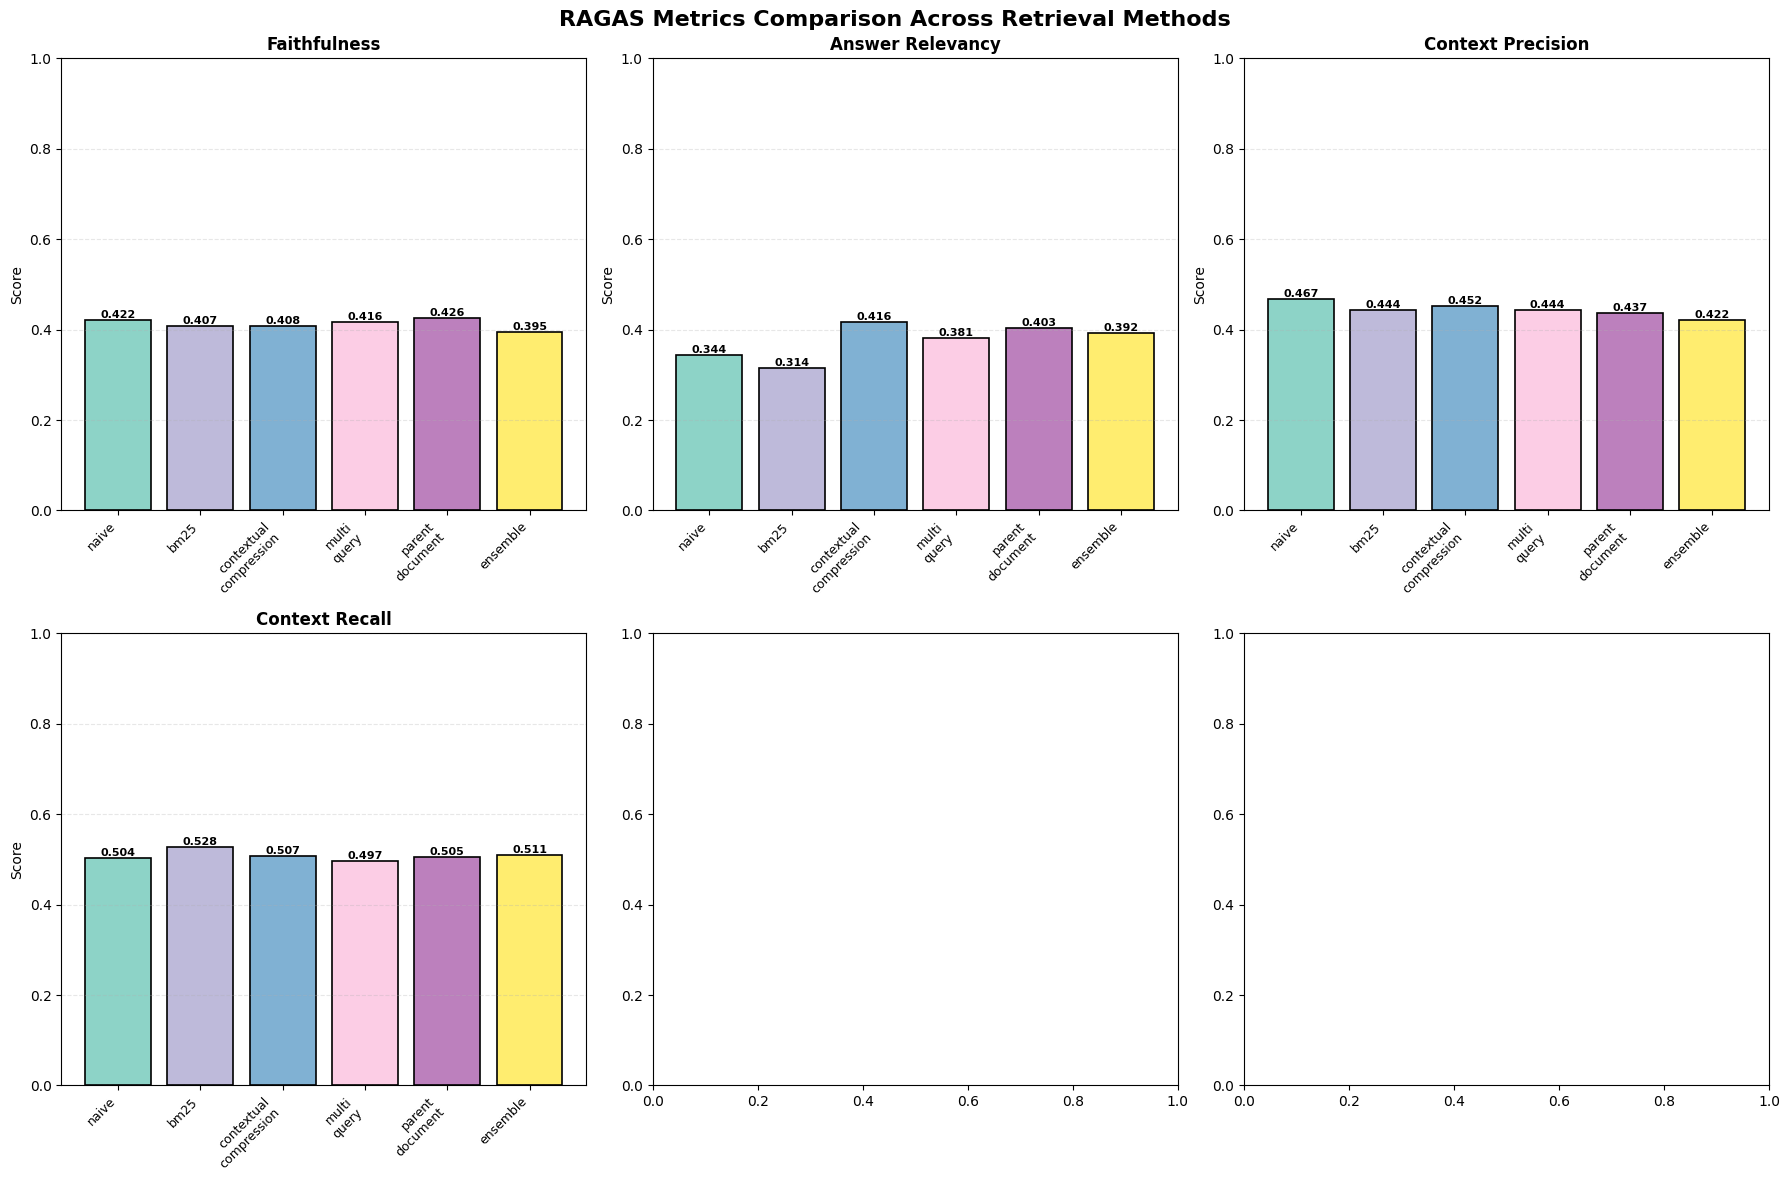

In [161]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Extract metrics from retriever_results
metrics_data = {}

for chain_name, result in retriever_results.items():
    metrics_data[chain_name] = result.to_pandas().drop(columns=['user_input', 'retrieved_contexts', 'response', 'reference']).mean().to_dict()

# Create DataFrame for easier plotting
metrics_df = pd.DataFrame(metrics_data).T
# Display the metrics table
print("📊 RAGAS Metrics Comparison Across Retrievers")
print("=" * 80)
print(metrics_df.round(4))
print("\n")

# Create visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('RAGAS Metrics Comparison Across Retrieval Methods', fontsize=16, fontweight='bold')

# Get metric names and retrievers
metric_names = list(metrics_df.columns)
retrievers = list(metrics_df.index)

# Color palette
colors = plt.cm.Set3(np.linspace(0, 1, len(retrievers)))

# Plot each metric in a subplot
for idx, metric in enumerate(metric_names):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    values = metrics_df[metric].values
    bars = ax.bar(range(len(retrievers)), values, color=colors, edgecolor='black', linewidth=1.2)
    
    # Customize subplot
    ax.set_title(metric.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.set_xticks(range(len(retrievers)))
    ax.set_xticklabels([r.replace('_retrieval_chain', '').replace('_', '\n') for r in retrievers], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Score', fontsize=10)
    ax.set_ylim(0, 1.0)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels on bars
    for i, (bar, value) in enumerate(zip(bars, values)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{value:.3f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

##### Submittal Query helpers

In [68]:
import json, re
from typing import List, Dict, Any, Optional, Tuple
from langchain_core.documents import Document

# ---- guardrails: evidence substring + simple numeric sanity (optional) ----

UNIT_SYNONYMS = {
    "fpm": ["fpm","ft/min","feet per minute"],
    "in":  ["in","inch","inches","\""],
    "mm":  ["mm","millimeter","millimeters"],
    "lb":  ["lb","lbs","pound","pounds"],
    "v":   ["v","vac","vdc","volts"],
}

# Optional policy keyed by canonical attribute (use if available)
POLICY_BY_CANONICAL = {
    # "rated_speed": {"abs": 5.0},
    # "door_width":  {"abs": 0.25},
}

DEFAULT_TOLERANCES_BY_UNIT = {
    "fpm": {"abs": 5.0},
    "in":  {"abs": 0.25},
    "mm":  {"abs": 2.0},
    "lb":  {"pct": 0.0},
}

_NUMUNIT = re.compile(r'(-?\d+(?:[\d,]*)(?:\.\d+)?)\s*([a-zA-Z/%°]+)?')

def _parse_num_unit(s: str) -> Optional[Tuple[float, str]]:
    m = _NUMUNIT.search((s or "").replace(",", ""))
    if not m: return None
    try: return float(m.group(1)), (m.group(2) or "").lower()
    except: return None

def evidence_ok(evidence: str, chunk_text: str) -> bool:
    return bool(evidence) and (evidence in chunk_text)

def numeric_sanity(spec_fact: Dict[str, Any], evidence: str,
                   tol_abs: float = 0.0, tol_pct: float = 0.0) -> bool:
    v = spec_fact.get("value", {})
    if v.get("type") not in {"quantity","range"}:
        return True
    parsed = _parse_num_unit(evidence)
    if v.get("type") == "range":
        if not parsed: return False
        x, _ = parsed
        lo, hi = float(v["min"]), float(v["max"])
        return (lo - tol_abs) <= x <= (hi + tol_abs)
    if not parsed: return False
    x, _ = parsed
    tgt = v.get("num")
    if tgt is None: return True
    tgt = float(tgt)
    op = spec_fact.get("op","=")
    if op == "=":  return abs(x - tgt) <= max(tol_abs, tol_pct * max(abs(x), abs(tgt), 1e-9))
    if op == ">=": return x + tol_abs >= tgt
    if op == "<=": return x - tol_abs <= tgt
    if op == ">":  return x > tgt
    if op == "<":  return x < tgt
    if op == "~":  return abs(x - tgt) <= max(tol_abs, tol_pct * max(abs(x), abs(tgt)))
    return True

def score_candidate(verdict: str, chunk_text: str, spec_fact: Dict[str, Any],
                    tier: str, evidence: str) -> float:
    s = 0.0
    s += 2.0 if verdict == "consistent" else 0.8 if verdict == "inconsistent" else 0.2
    s += 0.4 if tier in {"technical","submittal"} else 0.2 if tier == "brochure" else 0.0
    unit = (spec_fact.get("value") or {}).get("unit","")
    if unit and unit.lower() in (chunk_text or "").lower():
        s += 0.2
    if evidence: s += 0.2
    return s

def _norm_ws(s: str) -> str:
    return re.sub(r"\s+", " ", s.strip())

def _quote_if_multi(s: str) -> str:
    return f'"{s}"' if " " in s else s

def _expand_phrase(p: str) -> List[str]:
    """Expand without ever removing spaces entirely."""
    p = _norm_ws(p)
    forms = {p}

    # hyphen <-> space
    if "-" in p:
        forms.add(_norm_ws(p.replace("-", " ")))
    if " " in p:
        forms.add(_norm_ws(p.replace(" ", "-")))

    # slash variants
    if "/" in p:
        forms.add(_norm_ws(p.replace("/", " / ")))
        forms.add(_norm_ws(p.replace("/", " ")))      # treat slash as a space

    # ampersand variants
    if "&" in p:
        forms.add(_norm_ws(p.replace("&", "and")))
        forms.add(_norm_ws(p.replace("&", " and ")))

    # never return a no-space concatenation
    out = []
    for f in forms:
        if f and not re.search(r"\S\s*\S", f) and " " not in f and "-" not in f and "/" not in f:
            # single token already; keep as is
            out.append(f)
        else:
            out.append(f)
    # quote multiword for sparse channel
    return [_quote_if_multi(x) for x in sorted(set(out)) if x]

def _numeric_terms(v: Dict[str, Any]) -> List[str]:
    terms = []
    if v.get("num") is None:
        return terms
    num = v["num"]
    unit = (v.get("unit") or "").lower()
    if not unit:
        return [str(num)]
    terms.append(f"{num} {unit}")
    # unit synonyms (e.g., inch → " and 3-inch)
    for u in UNIT_SYNONYMS.get(unit, []):
        if u == '"':
            # 3"
            terms.append(f'{num}"')
        else:
            terms.append(f"{num} {u}")
            # hyphenated numeric form for adjectives (e.g., 3-inch)
            if u in {"in", "inch", "inches"}:
                terms.append(f"{num}-inch")
    return list(dict.fromkeys(terms))

def _value_text_terms(v: Dict[str, Any]) -> List[str]:
    if v.get("type") == "quantity":
        return []
    raw = (v.get("raw") or "").strip()
    if not raw:
        return []
    # Keep the full phrase (quoted), plus gentle sub-phrases
    out = _expand_phrase(raw)
    # Add 1–2 informative tokens (no concatenation)
    tokens = [t for t in re.findall(r"[a-z0-9][a-z0-9\-&/]*", raw.lower()) if len(t) > 2]
    for t in tokens[:6]:
        out += _expand_phrase(t)
    # dedupe
    seen, clean = set(), []
    for x in out:
        if x not in seen:
            seen.add(x); clean.append(x)
    return clean[:20]

def build_query_terms_open(spec_fact: Dict[str, Any]) -> Dict[str, Any]:
    attr_raw = (spec_fact.get("attribute", {}) or {}).get("raw", "").strip()
    v = spec_fact.get("value", {}) or {}
    ent = spec_fact.get("entity", {}) or {}

    # Dense query: short, grammatical (for embeddings)
    subject = ent.get("type") or ""
    dense_bits = [subject, attr_raw, v.get("raw","") if v.get("type") != "quantity" else ""]
    dense_query = " ".join(b for b in dense_bits if b).strip()
    if dense_query:
        dense_query = f"Find submittal statements about {dense_query}."
    else:
        dense_query = attr_raw or subject or "product requirement"

    # Sparse terms: attribute + value expansions + numeric/unit variants + light entity hints
    sparse_terms: List[str] = []
    if attr_raw:
        sparse_terms += _expand_phrase(attr_raw)

    if v.get("type") == "quantity":
        sparse_terms += _numeric_terms(v)
    else:
        sparse_terms += _value_text_terms(v)

    for k in ("manufacturer","name","type"):
        if ent.get(k):
            sparse_terms += _expand_phrase(str(ent[k]))

    # Final cleanup & limit
    seen, sparse_terms_clean = set(), []
    for t in sparse_terms:
        t = t.strip()
        if not t or t in seen:
            continue
        # Reject accidental no-space concatenations (defensive)
        if re.search(r"[A-Za-z]{2,}[A-Z][a-z]+", t):  # CamelCase joins
            continue
        if " " not in t and "-" not in t and "/" not in t and '"' not in t and len(t) > 25:
            # very long single token is likely a concatenation—drop it
            continue
        seen.add(t)
        sparse_terms_clean.append(t)
    sparse_terms_clean = sparse_terms_clean[:20]

    return {
        "dense": dense_query,
        "sparse": {
            "must": sparse_terms_clean[:1] if sparse_terms_clean else [],
            "should": sparse_terms_clean[1:],
            "boost": ({sparse_terms_clean[0]: 2.5} if sparse_terms_clean else {})
        }
    }

def _strip_quotes(s: str) -> str:
    return s.strip('"')

def bm25_query_from_sparse(sparse: dict) -> str:
    """
    Build a token query for rank_bm25:
    - Join must+should
    - Emulate boosts by repeating boosted terms
    - Quotes don't help rank_bm25, so we strip them (we keep phrases for post-filter)
    """
    parts = []
    must = [ _strip_quotes(t) for t in sparse.get("must", []) ]
    should = [ _strip_quotes(t) for t in sparse.get("should", []) ]
    parts += must + should

    for term, w in (sparse.get("boost") or {}).items():
        term = _strip_quotes(term)
        parts += [term] * int(round(max(1.0, w)))  # repeat to emulate boost

    # rank_bm25 tokenizes on whitespace; this is fine
    return " ".join(parts)

def contains_phrase(doc_text: str, phrase: str) -> bool:
    """Simple phrase check; also try hyphen<->space swap."""
    t = phrase.lower().strip()
    text = doc_text.lower()
    if t in text:
        return True
    # hyphen-space variants
    if "-" in t and t.replace("-", " ") in text:
        return True
    if " " in t and t.replace(" ", "-") in text:
        return True
    return False

def enforce_must_phrases(docs: list[Document], sparse: dict) -> list[Document]:
    must_phrases = [ _strip_quotes(t) for t in sparse.get("must", []) ]
    if not must_phrases:
        return docs
    out = []
    for d in docs:
        if all(contains_phrase(d.page_content, m) for m in must_phrases):
            out.append(d)
    # if over-strict filter wipes everything, fail open
    return out or docs

def tolerances_for_fact(spec_fact: dict,
                        policy_by_canonical: dict | None = None,
                        default_by_unit: dict | None = None) -> tuple[float, float]:
    policy_by_canonical = policy_by_canonical or {}
    default_by_unit = default_by_unit or DEFAULT_TOLERANCES_BY_UNIT

    # 1) explicit tolerance in the fact (from “±” parse) wins
    tol = (spec_fact.get("qualifiers") or {}).get("tolerance")
    if tol and "plus_minus" in tol:
        return float(tol["plus_minus"]), 0.0

    # 2) policy by canonical
    canon = spec_fact.get("attribute", {}).get("canonical")
    if canon and canon in policy_by_canonical:
        t = policy_by_canonical[canon]
        return float(t.get("abs", 0.0)), float(t.get("pct", 0.0))

    # 3) fallback by unit
    unit = (spec_fact.get("value") or {}).get("unit", "")
    t = default_by_unit.get((unit or "").lower(), {})
    return float(t.get("abs", 0.0)), float(t.get("pct", 0.0))

#### Comparator

##### Test the BM25 Retriever with **Sparse** query

In [115]:
# BM25
spec_json_fact = processed_spec_facts[80]
q = build_query_terms_open(spec_json_fact)
print(f"Query derived from spec_fact:\n")
print(json.dumps(q, indent=2))
print("\n")

bm25_query = bm25_query_from_sparse(q["sparse"])
print(f"Query after boost:\n")
print(bm25_query)
print("\n")

bm25_retriever = create_bm25_retriever()
bm25_docs = bm25_retriever.get_relevant_documents(bm25_query)
print(f"BM25 docs:\n")
print(bm25_docs)
print("\n")

bm25_docs = enforce_must_phrases(bm25_docs, q["sparse"])
print(f"BM25 docs after must phrases:\n")
print(bm25_docs)
print("\n")



Query derived from spec_fact:

{
  "dense": "Find submittal statements about elevator car-control stations manufacturer's standard recessed car-control stations.",
  "sparse": {
    "must": [
      "\"car control stations\""
    ],
    "should": [
      "\"car-control stations\"",
      "car-control-stations",
      "\"manufacturer's standard recessed car control stations\"",
      "\"manufacturer's standard recessed car-control stations\"",
      "manufacturer's-standard-recessed-car-control-stations",
      "manufacturer",
      "standard",
      "recessed",
      "\"car control\"",
      "car-control",
      "stations",
      "elevator"
    ],
    "boost": {
      "\"car control stations\"": 2.5
    }
  }
}


Query after boost:

car control stations car-control stations car-control-stations manufacturer's standard recessed car control stations manufacturer's standard recessed car-control stations manufacturer's-standard-recessed-car-control-stations manufacturer standard recessed ca

In [ ]:
# Load your attribute catalog dict
# CSI_SPEC_ATTR_CATALOG_FILE_PATH="./spec_attributes_catalog.yaml"
# catalog = yaml.safe_load(open(CSI_SPEC_ATTR_CATALOG_FILE_PATH))

for spec_json_fact in processed_spec_facts:
    query = build_query_terms_open(spec_json_fact)
    print(f"Query derived from spec_fact:\n")
    print(json.dumps(query, indent=2))
    print("\n")

In [ ]:
# Minimal example spec_fact (use your Pass B/C output)

# Load your attribute catalog dict
CSI_SPEC_ATTR_CATALOG_FILE_PATH="./spec_attributes_catalog.yaml"
catalog = yaml.safe_load(open(CSI_SPEC_ATTR_CATALOG_FILE_PATH))

print(f"# Spec Facts: {len(processed_spec_facts)}")
comparator_results = []
# Run the chain
for spec_json_fact in processed_spec_facts:
    query = build_query_terms_open(spec_json_fact, catalog)
    state_in = {
        "spec_fact": spec_json_fact,
        "query": query,
    }
    print(f"Query: {query}")
    # result_state = rag_naive_retriveval_chain.invoke(state_in)
    bm25_retrieval_chain = retriever_chains_dict["bm25_retrieval_chain"]
    result_state = bm25_retrieval_chain.invoke(state_in)
    comparator_results.append(result_state["result"])
    print(json.dumps(result_state["result"], indent=2))

# Dump comparator_results to a file in JSON format for further inspection/debugging.
# Ensure the .vibe-log/ directory exists (as per general-rule)

comp_results_path = DATA_DIR / 'bm25_chain_comparator_results.json'
try:
    with open(comp_results_path, 'w', encoding='utf-8') as f:
        json.dump(comparator_results, f, ensure_ascii=False, indent=2)
    logging.info(f"Comparator results dumped to {comp_results_path}")
except Exception as e:
    logging.error(f"Failed to write comparator_results to file: {str(e)}")

